### Main paper plot 3.5

Experiments on HotpotQA to compare with the ground truth relationships.

Exp 3.5.1: F(S*(Q), Q) vs F(S(Q), Q) for S(Q) from all?/some? methods. In this case, X-axis is K upto 3.

Exp 3.5.2: MAP on ranking obtained by checking if S_1, S_2/S_1, S_3/S_2 and so on are within S^*. Table of MAP values 

In [63]:
import torch
import pickle
import os
import numpy as np
import sys
from tqdm import tqdm

from omegaconf import OmegaConf
from src.utils import partial_chamfer_sim
from src.embedder import ColBERTEmbedder

In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm

In [3]:
from plot_utils import crop_pdf_with_fitz, crop_pdf_with_pdfcrop, crop_pdf_with_pypdf,\
    legend_labels, method_label_map, methods, legend_color_map, legend_marker_map

In [4]:
methods = methods + ['gold']

In [5]:
%load_ext autoreload
%autoreload 1

%aimport plot_utils

In [6]:
datasets = ['hotpotqa']
time_map, max_time_vals = plot_utils.get_time_data(datasets)

hotpotqa


In [412]:
# Load score data
score_map = {ds: {} for ds in datasets}
score_map_full = {ds: {} for ds in datasets}
ind_map = {ds: {} for ds in datasets}

for ds in datasets:
    for method in methods:
        if method == "gold":
            continue
        inds, scores = plot_utils.get_score_data(ds, method, k=10)
        print(f"Shapes for {ds}, {method}: inds: {inds.shape}, scores: {scores.shape}")
        assert inds.shape == scores.shape, f"Shape mismatch for {ds}, {method}: inds: {inds.shape}, scores: {scores.shape}"
        assert inds.shape[0] > 10
        score_map[ds][method] = scores.mean(dim=0).numpy()
        score_map_full[ds][method] = scores.numpy()
        ind_map[ds][method] = inds

Method is submodlib lazy, loading from /mnt/nas/pritish/DGX/CMUVERA_IR_ref/pickles/results/greedy_submodlib_LazyGreedy_k10_hotpotqa_bf_k10_submodlib_no_stop.pkl
File not found: greedy_submodlib_LazyGreedy_k10_hotpotqa_bf_k10_submodlib_no_stop.pkl
submodlib lazy + hotpotqa does not have k=10 data, defaulting to k=15
Shapes for hotpotqa, submodlib lazy: inds: torch.Size([7405, 10]), scores: torch.Size([7405, 10])
Method is submodlib stochastic 0.5, loading from /mnt/nas/pritish/DGX/CMUVERA_IR_ref/pickles/results/greedy_submodlib_StochasticGreedy_k10_hotpotqa_bf_k10_submodlib_no_stop_eps0.5.pkl
Shapes for hotpotqa, submodlib stochastic 0.5: inds: torch.Size([7405, 10]), scores: torch.Size([7405, 10])
Method is submodlib ltl 0.1, loading from /mnt/nas/pritish/DGX/CMUVERA_IR_ref/pickles/results/greedy_submodlib_LazierThanLazyGreedy_k10_hotpotqa_bf_k10_submodlib_no_stop.pkl
File not found: greedy_submodlib_LazierThanLazyGreedy_k10_hotpotqa_bf_k10_submodlib_no_stop.pkl
submodlib ltl 0.1 + hot

In [145]:
ind_map['hotpotqa']

{'submodlib lazy': tensor([[ 644131,  199468,  229845,  ..., 3520383, 4011270, 1479580],
         [3449910,  294495, 3356140,  ..., 2138381,  267120, 3213082],
         [2239013, 1635384,  834039,  ..., 4817227,  225595, 2550833],
         ...,
         [1276830,  576636, 2768597,  ...,  325668, 2517828,  780505],
         [ 502395,  281560, 3450187,  ...,  370988,  554116, 1301100],
         [ 324893, 3937242, 1316886,  ..., 2048950, 3928598,  870223]]),
 'submodlib stochastic 0.5': tensor([[   4758,  726273, 1371281,  ..., 2786744,  470638, 1338827],
         [2847275,  403561,  294495,  ..., 3610691, 3449910, 4930397],
         [1053275, 1253143, 2949927,  ..., 4837854, 4623930, 1932902],
         ...,
         [ 409132,  835720,  576636,  ..., 1011361,  182702,  942682],
         [ 502395, 5058161, 4422117,  ..., 4724975, 1301100, 4269098],
         [1323224, 2658633, 4505225,  ..., 1316886, 1885466,  300458]]),
 'submodlib ltl 0.1': tensor([[   4758,  605191,  644131,  ...,  90873

In [10]:
# Load ground truth data for HotpotQA
from src.dataloader import get_dataloader

class DummyConfig:
    loader_type = 'beir'
    dataset_name = 'hotpotqa'

dataloader = get_dataloader(DummyConfig())

In [11]:
qrels = dataloader.get_qrels()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5233329/5233329 [00:26<00:00, 200848.24it/s]


In [39]:
corpus, queries = dataloader.get_data()
# corpus: Dict[str, Dict]
keys = list(map(str, corpus.keys()))      # preserve a stable order
id2idx = {k: i for i, k in enumerate(keys)}
idx2id = keys                              # idx -> doc_id

In [40]:
pos_indices = []
missing = []
for qrel_dict in qrels.values():                    # qrels: Dict[doc_id -> 1]
    pos_indices_q = []
    missing_q = []

    for k in qrel_dict.keys():
        kk = str(k)
        if kk in id2idx:
            pos_indices_q.append(id2idx[kk])
        else:
            missing_q.append(kk)                # log/debug if any don't match

    pos_indices.append(pos_indices_q)
    missing.extend(missing_q)


In [41]:
assert len(missing) == 0, f"Some qrels not found in corpus: {missing}"

In [42]:
assert len(pos_indices) == len(queries)

In [43]:
pos_indices[0]

[644131, 4758]

In [14]:
qrels.values()

dict_values([{'2816539': 1, '10520': 1}, {'33022480': 1, '804602': 1}, {'12342237': 1, '18974107': 1}, {'9421721': 1, '20395866': 1}, {'41146297': 1, '5382358': 1}, {'43665973': 1, '40901645': 1}, {'507437': 1, '282635': 1}, {'1922186': 1, '1922204': 1}, {'39354179': 1, '1316127': 1}, {'215890': 1, '10244818': 1}, {'28635126': 1, '163327': 1}, {'11835533': 1, '101813': 1}, {'7038717': 1, '2837025': 1}, {'16605491': 1, '17626850': 1}, {'14286443': 1, '43223': 1}, {'10426459': 1, '95743': 1}, {'38281459': 1, '531687': 1}, {'12958': 1, '356938': 1}, {'1473416': 1, '25473': 1}, {'2279815': 1, '504845': 1}, {'38828650': 1, '19801645': 1}, {'8539872': 1, '651486': 1}, {'2892101': 1, '2891685': 1}, {'428029': 1, '38759285': 1}, {'2482563': 1, '413284': 1}, {'1457187': 1, '1621134': 1}, {'32971919': 1, '172675': 1}, {'16298123': 1, '1277632': 1}, {'7586794': 1, '767631': 1}, {'55348267': 1, '30600': 1}, {'15549454': 1, '166643': 1}, {'978819': 1, '2281588': 1}, {'17215709': 1, '2880924': 1}, {

To generate the scores for the gold sets, we have to use partial_chamfer_sim the same way we do for iid baselines.
That means we have to load the query and corpus embeddings.


In [53]:
def make_conf():
    # k=15 embedder.mode="disk" augment=False method='baseline' data.loader_type=lotte data.query_type=forum data.dataset_name=writing index=True overwrite_index=True
    sys.argv = ["", f"k=10", f"embedder.mode=disk", f"augment=False", f"method=baseline",
            f"data.loader_type=lotte", f"data.query_type=forum", f"data.dataset_name=hotpotqa",
            "index=False", "overwrite_index=False"]
    print(sys.argv)
    cli_conf = OmegaConf.from_cli()
    main_conf = OmegaConf.load("configs/config.yaml")
    colbert_conf = OmegaConf.load("configs/colbert.yaml")

    conf = OmegaConf.merge(main_conf, colbert_conf, cli_conf)

    return conf

In [54]:
conf = make_conf()

['', 'k=10', 'embedder.mode=disk', 'augment=False', 'method=baseline', 'data.loader_type=lotte', 'data.query_type=forum', 'data.dataset_name=hotpotqa', 'index=False', 'overwrite_index=False']


In [56]:
embedder = ColBERTEmbedder(conf.embedder)

In [68]:
# Using pos_indices, we have to make a |Q| x max set size matrix of ground truth corpus items.
# Max set size means the largest number of relevant documents for any query.
# For padding purposes, we will repeat the last index in each query's list.
max_set_size = max(len(p) for p in pos_indices)
gt_indices = np.zeros((len(pos_indices), max_set_size), dtype=np.int32)
for i, p in enumerate(pos_indices):
    for j in range(max_set_size):
        if j < len(p):
            gt_indices[i, j] = p[j]
        else:
            gt_indices[i, j] = p[-1]
gt_indices = torch.from_numpy(gt_indices)

In [72]:
torch.cuda.is_available()

True

In [411]:
gt_indices.shape

torch.Size([7405, 2])

In [75]:
embedder.embed_full_dataset(dataloader, mode=conf.embedder.mode)
qembs, qmasks = embedder.qembs, embedder.qmasks
gold_chamfer_scores = []

gt_indices = gt_indices.to(embedder.device)
print("Getting the corpus embeddings...")
corpus = embedder.get_corpus(gt_indices)
print("Done getting corpus embeddings.")

print("Computing chamfer scores for gold sets...")

for query_id in tqdm(range(len(queries)), desc="Computing chamfer scores for gold sets"):
    qemb = qembs[query_id:query_id+1]       # (1, Lq, d)
    qmask = qmasks[query_id:query_id+1]     # (1, Lq)
    
    cemb, cmask = corpus[
        (query_id * torch.ones(gt_indices.shape[1], dtype=torch.long)),
        torch.arange(gt_indices.shape[1], dtype=torch.long)
    ]

    out = partial_chamfer_sim(qembs[query_id][qmasks[query_id].bool()], cemb, cmask, device='cuda', bs=1024)
    out_sum = out.sum(dim=0)
    sorted_inds = torch.argsort(out_sum, descending=True)
    sorted_out = out[:, sorted_inds]
    res = torch.cummax(sorted_out, dim=1)[0].sum(dim=0)
    gold_chamfer_scores.append(res)

/mnt/nas/pritish/DGX/CMUVERA_IR_ref/ColBERT/colbert/utils/amp.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler()



#> QueryTokenizer.tensorize(batch_text[0], batch_background[0], bsize) ==
#> Input: Were Scott Derrickson and Ed Wood of the same nationality?, 		 True, 		 None
#> Output IDs: torch.Size([32]), tensor([  101,     1,  2020,  3660, 18928,  3385,  1998,  3968,  3536,  1997,
         1996,  2168, 10662,  1029,   102,   103,   103,   103,   103,   103,
          103,   103,   103,   103,   103,   103,   103,   103,   103,   103,
          103,   103], device='cuda:0')
#> Output Mask: torch.Size([32]), tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')



/mnt/nas/pritish/DGX/CMUVERA_IR_ref/ColBERT/colbert/utils/amp.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast() if self.activated else NullContextManager()


./experiments/hotpotqa/BERT/corpus/compressed_128/batch_0.0.pkl
./experiments/hotpotqa/BERT/corpus/compressed_128/batch_1.0.pkl
./experiments/hotpotqa/BERT/corpus/compressed_128/batch_2.0.pkl
./experiments/hotpotqa/BERT/corpus/compressed_128/batch_3.0.pkl
./experiments/hotpotqa/BERT/corpus/compressed_128/batch_4.0.pkl
./experiments/hotpotqa/BERT/corpus/compressed_128/batch_5.0.pkl
./experiments/hotpotqa/BERT/corpus/compressed_128/batch_6.0.pkl
./experiments/hotpotqa/BERT/corpus/compressed_128/batch_7.0.pkl
./experiments/hotpotqa/BERT/corpus/compressed_128/batch_8.0.pkl
./experiments/hotpotqa/BERT/corpus/compressed_128/batch_9.0.pkl
./experiments/hotpotqa/BERT/corpus/compressed_128/batch_10.0.pkl
./experiments/hotpotqa/BERT/corpus/compressed_128/batch_11.0.pkl
./experiments/hotpotqa/BERT/corpus/compressed_128/batch_12.0.pkl
./experiments/hotpotqa/BERT/corpus/compressed_128/batch_13.0.pkl
./experiments/hotpotqa/BERT/corpus/compressed_128/batch_14.0.pkl
./experiments/hotpotqa/BERT/corpus/

Computing chamfer scores for gold sets: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 7405/7405 [00:02<00:00, 2512.36it/s]


In [76]:
# with open("./pickles/results/gold_chamfer_scores_hotpotqa.pkl", "wb") as f:
#     pickle.dump(gold_chamfer_scores, f)

In [111]:
with open(f"./pickles/results/gold_chamfer_scores_hotpotqa.pkl", "rb") as f:
    gold_chamfer_scores_try = pickle.load(f)

In [83]:
gold_chamfer_scores = torch.stack(gold_chamfer_scores).cpu().numpy()

In [85]:
gc_mean = gold_chamfer_scores.mean(axis=0)
gc_mean

array([20.54772 , 23.517984], dtype=float32)

In [148]:
def plot_paper(dataset_name, desired_methods, y_label=True):
    plt.clf()
    fig, ax = plt.subplots(figsize=(8, 6))
    markersize = 10

    plt.rcParams.update({
        'text.usetex': True,
        'text.latex.preamble': r'\usepackage{amsmath}',
        'font.family': 'serif',
        'figure.dpi': 300,
        'lines.markersize': markersize
    })

    for method in desired_methods:
        if method == "gold":
            scores = gc_mean
        else:
            scores = score_map[dataset_name][method].tolist()[:2]
        ax.plot(
            [1, 2],
            scores,
            label=method_label_map[method],
            color=legend_color_map[method_label_map[method]],
            marker=legend_marker_map[method_label_map[method]],
            linewidth=2,
            markersize=14,
        )

    # ax.set_title(f'{dataset_name}: F(S) vs K', fontsize=20)
    ax.set_xlabel(r'$\pmb{K_Q}\rightarrow$', fontsize=48)      # Increased axis label size
    if y_label:
        ax.set_ylabel(r'$\textbf{Avg}\quad\pmb{F(S_{K_Q}, Q)}$', fontsize=46) # Increased axis label size

    # Explicitly set tick label sizes
    ax.tick_params(axis='x', labelsize=50)  # Smaller X-axis tick labels
    ax.tick_params(axis='y', labelsize=50)  # Smaller Y-axis tick labels

    # Get current x-tick values and format them with LaTeX bold
    xticks = ax.get_xticks()
    xticklabels = [fr'$\mathbf{{{int(v)}}}$' for v in xticks]
    ax.set_xticklabels(xticklabels)

    # Get current y-tick values and format them with LaTeX bold
    yticks = ax.get_yticks()
    yticklabels = [fr'$\mathbf{{{int(v)}}}$' for v in yticks]
    ax.set_yticklabels(yticklabels)

    # ax.legend(fontsize=12)
    ax.grid(True)

    plt.tight_layout()
    plt.savefig(f'./notebooks/plots/{dataset_name.lower()}_plot3_5_1.pdf')
    plt.show()

In [149]:
def plot_legend_only(desired_methods, filename, ncol=3, auto_crop=True):
    # Create a figure for legend only
    fig, ax = plt.subplots(figsize=(8, 6))

    plt.rcParams.update({
        'text.usetex': True,
        'text.latex.preamble': r'\usepackage{amsmath}',
        'font.family': 'serif',
        'figure.dpi': 300,
    })
    
    for method in desired_methods:
        ax.plot(
            [], [],
            label=method_label_map[method],
            color=legend_color_map[method_label_map[method]],
            marker=legend_marker_map[method_label_map[method]],
            linewidth=2,
            markersize=10,
        )

    # Hide the plot area
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    # Create legend
    legend = ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.1),
        ncol=ncol,
        fontsize=25,
        frameon=False
    )

    # Save the figure
    output_path = f'./notebooks/plots/{filename}.pdf'
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0.1, dpi=300)
    plt.show()
    
    # Auto-crop the PDF if requested
    if auto_crop:
        # Try methods in order of preference
        cropped_path = crop_pdf_with_pdfcrop(output_path)
        if cropped_path is None:
            cropped_path = crop_pdf_with_fitz(output_path)
        if cropped_path is None:
            cropped_path = crop_pdf_with_pypdf(output_path)
        
        if cropped_path:
            # Replace original with cropped version
            os.rename(cropped_path, output_path)
            print(f"PDF automatically cropped: {output_path}")
        else:
            print("Auto-cropping failed, using matplotlib's bbox_inches='tight' only")

In [91]:
dms = ['ColBERT bypass - 1', 'submodlib ltl 0.5', 'exact greedy', 'MUVERA iid', 'submodlib lazy', 'WARP iid', 'submodlib stochastic 0.5', 'ColBERT iid', 'gold']

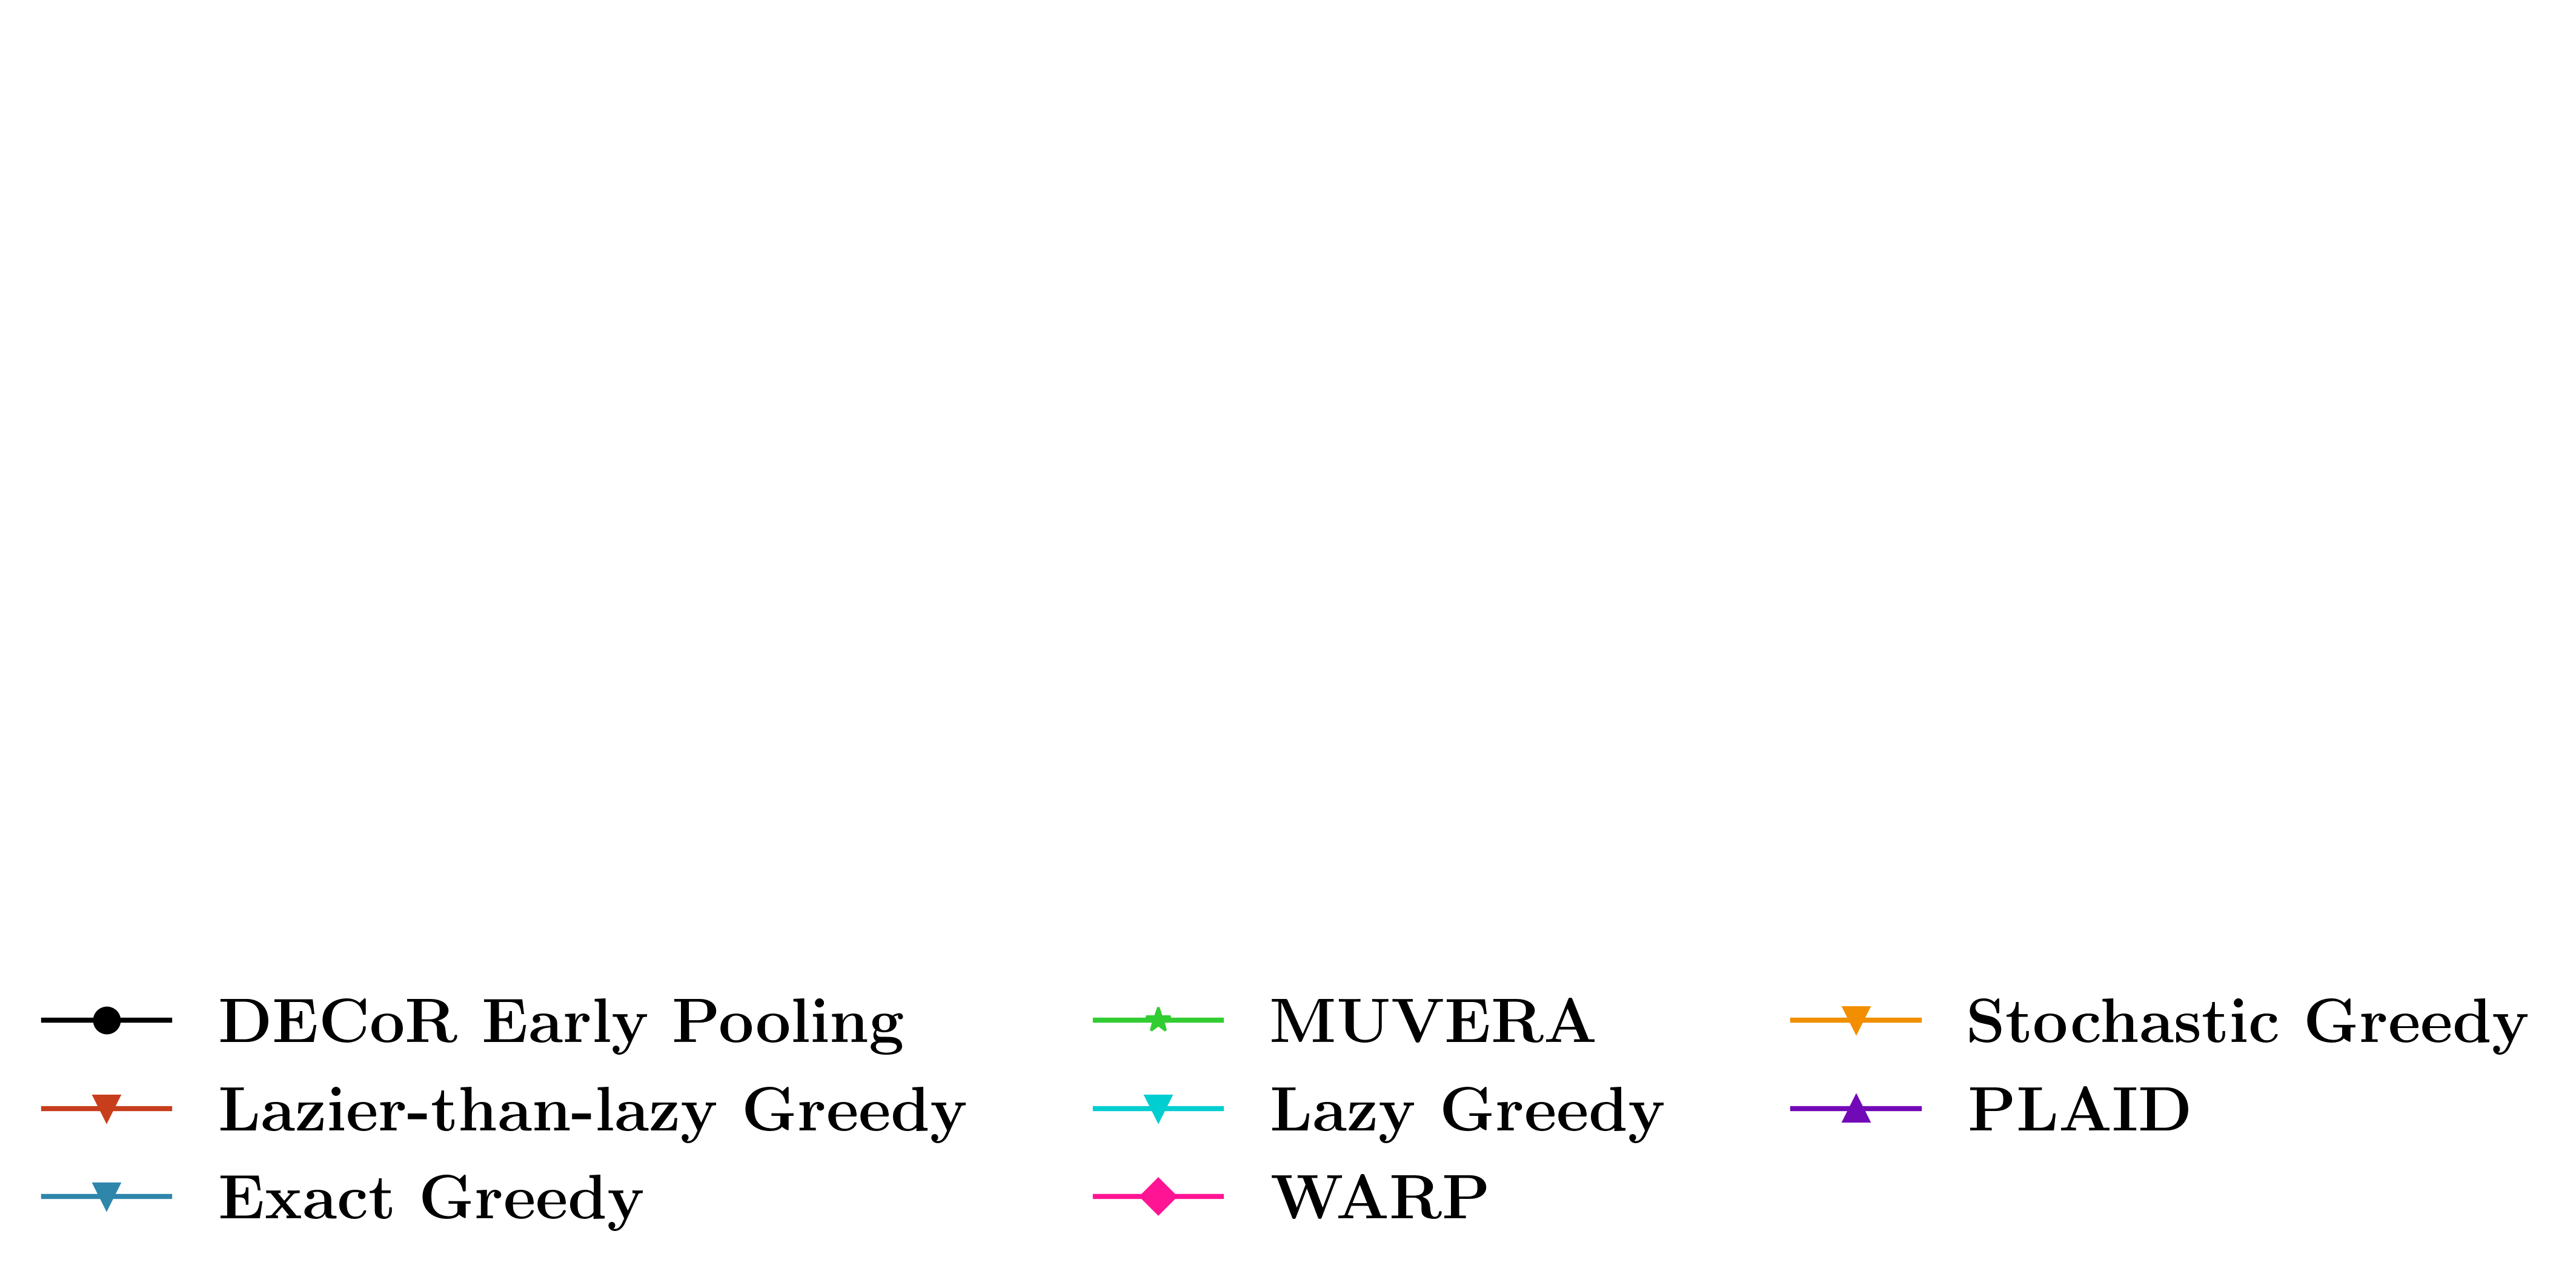

Successfully cropped ./notebooks/plots/plot3_5_1_legend.pdf -> ./notebooks/plots/plot3_5_1_legend_cropped.pdf
PDF automatically cropped: ./notebooks/plots/plot3_5_1_legend.pdf


In [387]:
plot_legend_only(dms, "plot3_5_1_legend", ncol=3)

/tmp/ipykernel_979059/1563038517.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)
/tmp/ipykernel_979059/1563038517.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(yticklabels)


<Figure size 1920x1440 with 0 Axes>

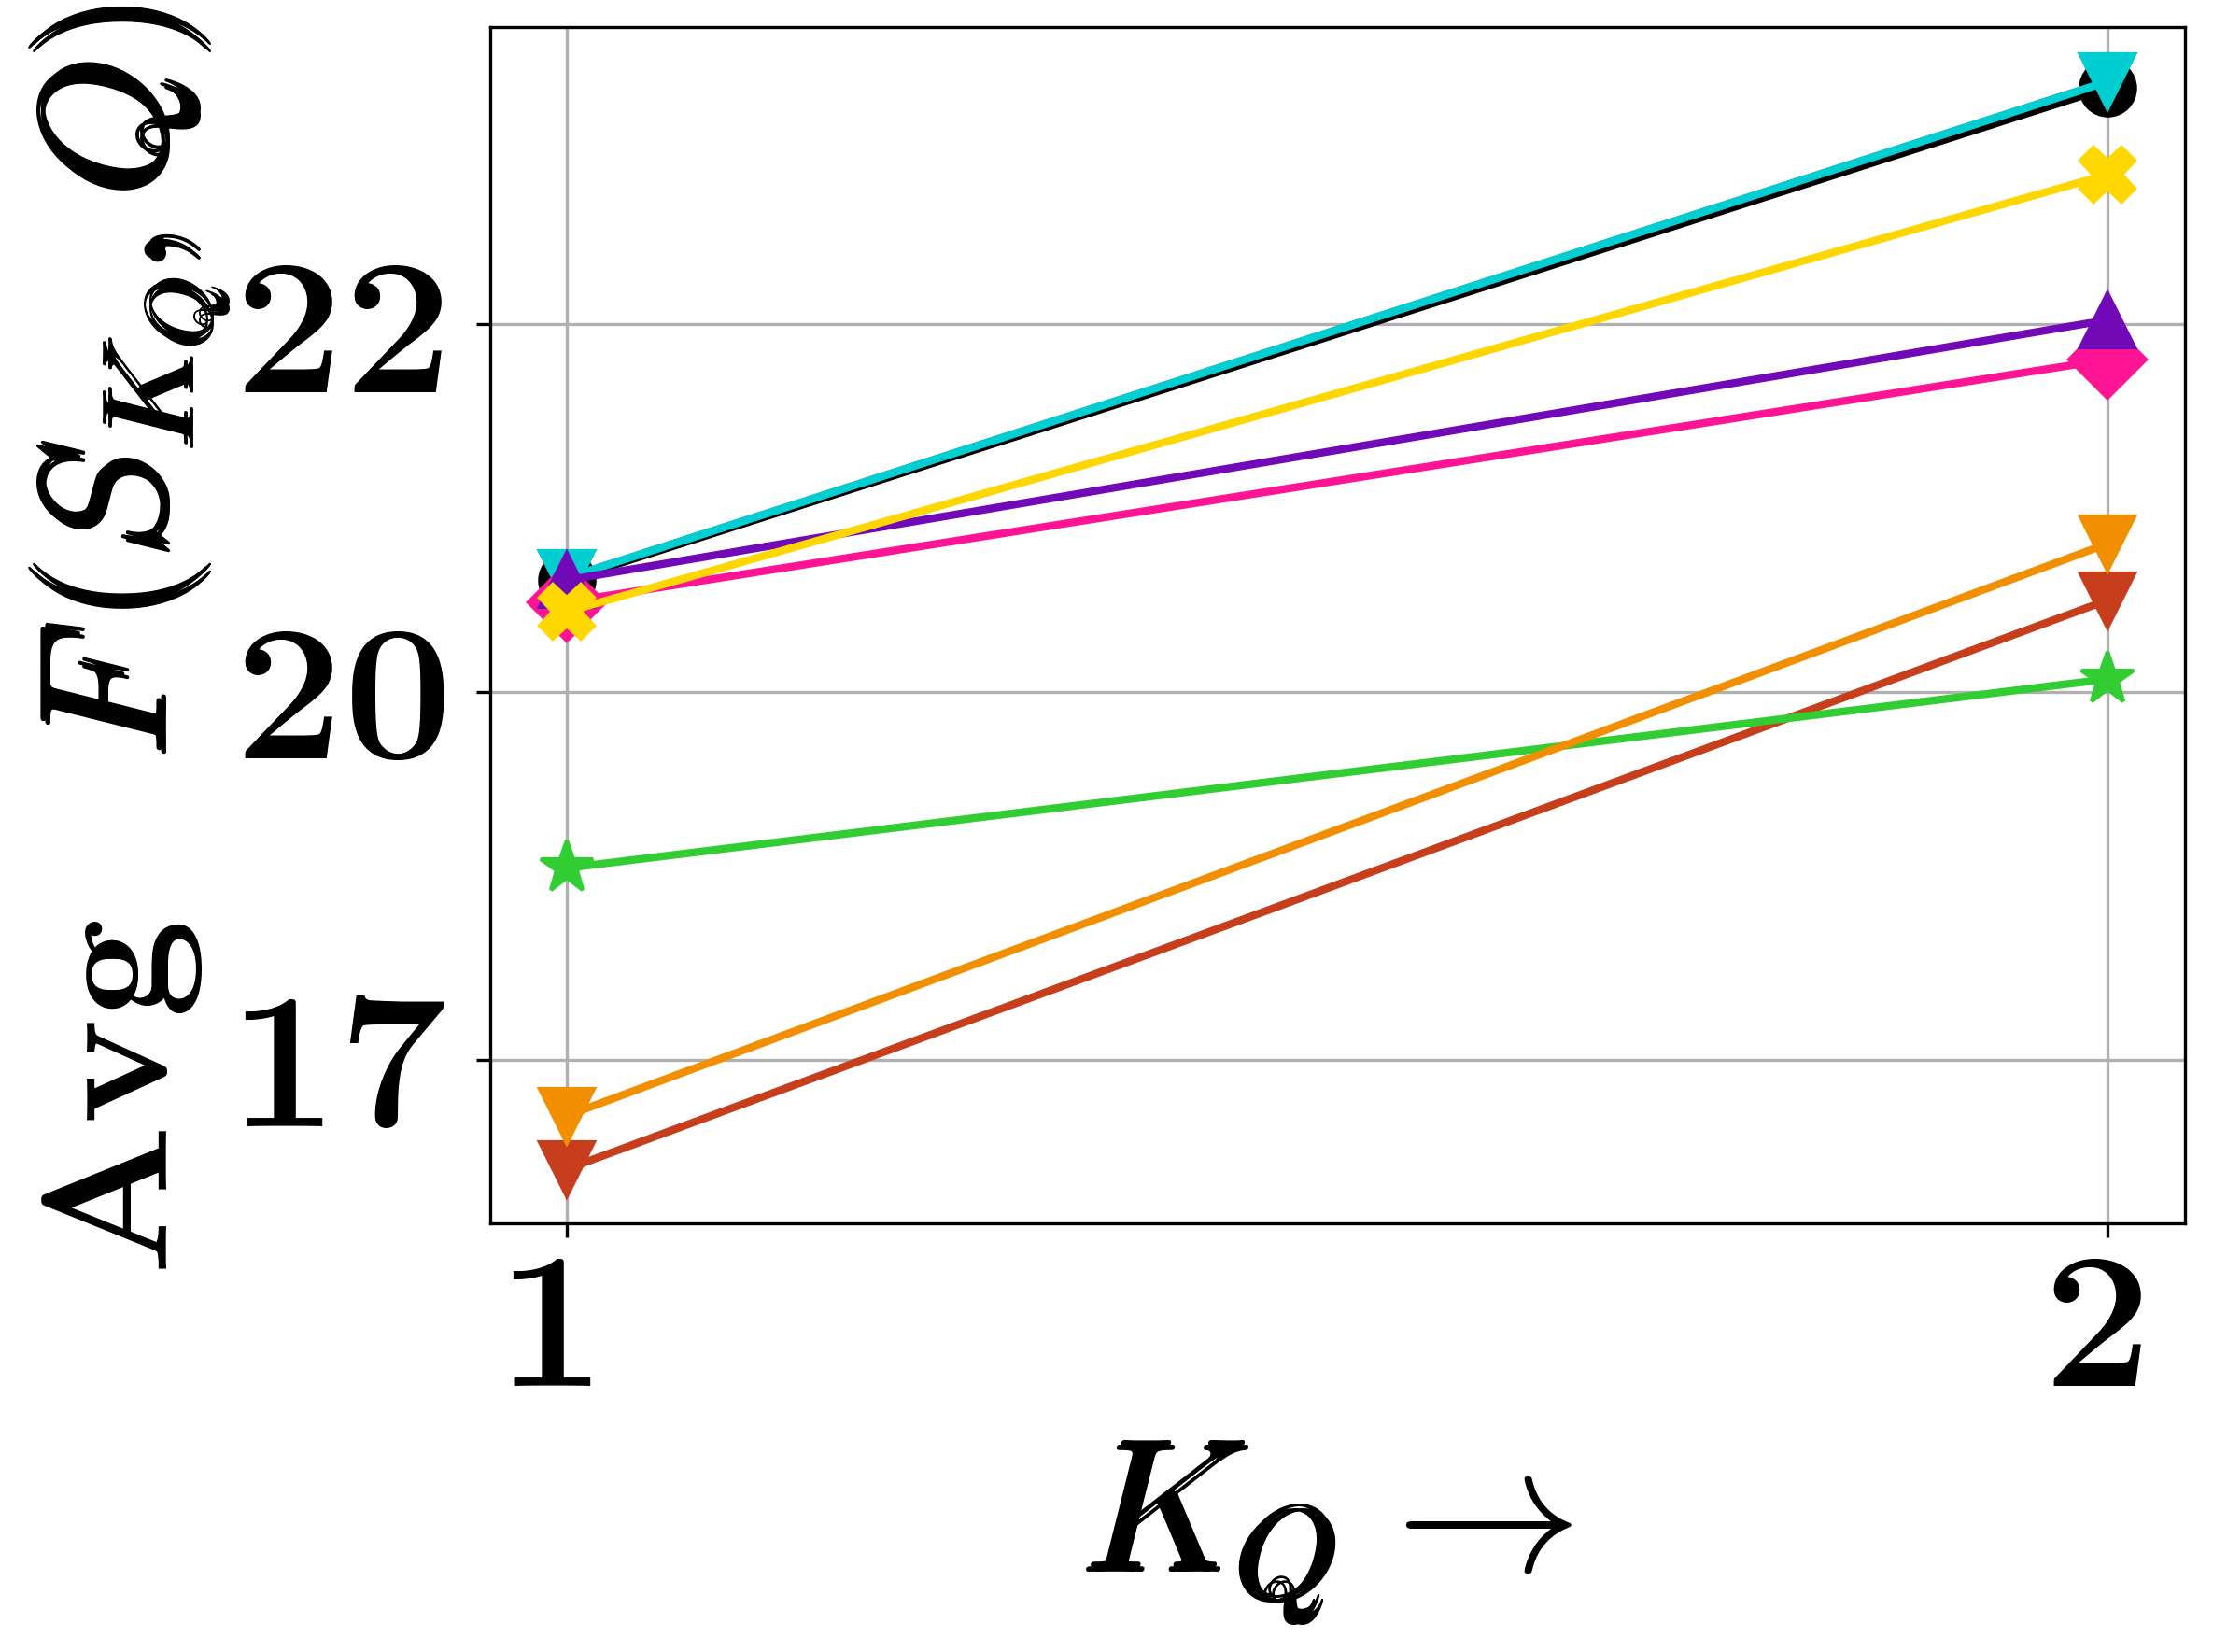

In [150]:
plot_paper("hotpotqa", dms, y_label=True)

In [129]:
ind_map["hotpotqa"].keys()

dict_keys(['submodlib lazy', 'submodlib stochastic 0.5', 'submodlib ltl 0.1', 'submodlib ltl 0.5', 'submodlib ltl 0.9', 'exact greedy', 'WARP iid', 'MUVERA iid', 'ColBERT iid', 'ColBERT bypass - 1', 'ColBERT angiogram - 1'])

In [ ]:
# Get the scores at S_2: this is |mean(F(S_2, Q)) - mean(F(S_2*, Q))|, probably *not* what we want.
for method in dms:
    if method == "gold":
        continue
    else:
        scores = score_map["hotpotqa"][method].tolist()[1]
        scores = np.abs(scores - gc_mean[1])
    print(f"Method: {method}, Score difference at S_2: {scores}")

Method: ColBERT bypass - 1, Score difference at S_2: 0.5906162261962891
Method: submodlib ltl 0.5, Score difference at S_2: 2.8910446166992188
Method: exact greedy, Score difference at S_2: 0.6320915222167969
Method: MUVERA iid, Score difference at S_2: 3.4279556274414062
Method: submodlib lazy, Score difference at S_2: 0.6320915222167969
Method: WARP iid, Score difference at S_2: 1.2567710876464844
Method: submodlib stochastic 0.5, Score difference at S_2: 2.507211685180664
Method: ColBERT iid, Score difference at S_2: 0.9879875183105469


In [415]:
# Get the scores at S_2: this is \sum_Q |F(S_2, Q) - F(S_2*, Q)| / |Q|, probably what we want.
mean_score_diffs = {method: 0.0 for method in dms if method != "gold"}
diffs = []
for method in dms:
    for qid in range(len(queries)):
        if method == "gold":
            continue
        else:
            score = score_map_full["hotpotqa"][method][qid].tolist()[1]
            score_diff = np.abs(score - gold_chamfer_scores[qid][1])
            # print(f"QID: {qid}, Method: {method}, Score difference at S_2: {score_diff}")
            mean_score_diffs[method] += score_diff
    mean_score_diffs[method] /= len(queries)
    diffs.append(mean_score_diffs[method])
    print(f"Method: {method}, Mean score difference at S_2: {mean_score_diffs[method]}")

srt_inds = np.argsort(diffs)
print("Method ranking:")
pprint.pprint([(dms[i], diffs[i]) for i in srt_inds])

Method: ColBERT bypass - 1, Mean score difference at S_2: 0.6815157844600124
Method: submodlib ltl 0.5, Mean score difference at S_2: 3.0993044073399783
Method: exact greedy, Mean score difference at S_2: 0.6906522191915054
Method: MUVERA iid, Mean score difference at S_2: 3.551279834796254
Method: submodlib lazy, Mean score difference at S_2: 0.6906522124945352
Method: WARP iid, Mean score difference at S_2: 1.5178220902158954
Method: submodlib stochastic 0.5, Mean score difference at S_2: 2.7758571736801323
Method: ColBERT iid, Mean score difference at S_2: 1.3069972127776626
Method ranking:
[('ColBERT bypass - 1', 0.6815157844600124),
 ('submodlib lazy', 0.6906522124945352),
 ('exact greedy', 0.6906522191915054),
 ('ColBERT iid', 1.3069972127776626),
 ('WARP iid', 1.5178220902158954),
 ('submodlib stochastic 0.5', 2.7758571736801323),
 ('submodlib ltl 0.5', 3.0993044073399783),
 ('MUVERA iid', 3.551279834796254)]


### Experiment 3.5.2

In [ ]:
from sklearn.metrics import average_precision_score
from tqdm import tqdm

map_dict = {method: {} for method in methods if method != "gold"}

# print(f"Gold set for query 543: {pos_indices[543]}")

for method in tqdm(methods, desc="Computing MAP for methods"):
    if method == 'gold':
        continue
    ap_list = []
    for q in tqdm(range(len(queries)), desc="Computing AP for queries"):
        gold_set = set(pos_indices[q])
        seen_so_far = set()
        y_gold = []
        count = 0
        y_score = []

        # print(f"Method {method}, Retrieved indices: {ind_map['hotpotqa'][method][q].tolist()}")
        # print(f"Method: {method}, Intersection: {gold_set.intersection(set(ind_map['hotpotqa'][method][q].tolist()))}")

        for element in ind_map['hotpotqa'][method][q]:
            element = element.item()
            if element in seen_so_far:
                break

            count = count + 1
            y_score.append(1/(count + 1))
            if element in gold_set:
                y_gold.append(1)
            else:
                y_gold.append(0)

            seen_so_far.add(element)

        # print(f"Element: {element}, y_gold: {y_gold}, y_score: {y_score}")

        ap = average_precision_score(y_gold, y_score)
        ap_list.append(ap)

    print(f"MAP for gold: {np.mean(ap_list)}")
    map_dict[method] = np.mean(ap_list)

In [176]:
def compute_precision_acc(labels, predictions):
    sorted_predictions = sorted(((e, i) for i, e in enumerate(predictions)), reverse=True)
    precision = 0.0
    r = int(sum(labels))
    j = 1
    for i in range(len(sorted_predictions)):
        if labels[sorted_predictions[i][1]] == 1.0:
            precision += 1.0 * j / (i+1) / r
            j += 1

    return precision

In [ ]:
from sklearn.metrics import average_precision_score
from tqdm import tqdm

mrr_dict = {method: {} for method in methods if method != "gold"}
map_dict_1 = {method: {} for method in methods if method != "gold"}
map_dict_2 = {method: {} for method in methods if method != "gold"}


# print(f"Gold set for query 543: {pos_indices[543]}")

for method in tqdm(methods, desc="Computing MAP for methods"):
    if method == 'gold':
        continue
    ap_list = []
    other_ap_list = []
    rr_list = []

    for q in tqdm(range(len(queries)), desc="Computing AP for queries"):
        gold_set = set(pos_indices[q])
        seen_so_far = set()
        y_gold = []
        count = 0
        y_score = []
        rr = 0

        # print(f"Method {method}, Retrieved indices: {ind_map['hotpotqa'][method][q].tolist()}")
        # print(f"Method: {method}, Intersection: {gold_set.intersection(set(ind_map['hotpotqa'][method][q].tolist()))}")

        for element in ind_map['hotpotqa'][method][q]:
            element = element.item()
            if element in seen_so_far:
                break

            count = count + 1
            y_score.append(1/(count))
            if element in gold_set:
                y_gold.append(1)
                if rr == 0:
                    rr = 1/count
            else:
                y_gold.append(0)

            seen_so_far.add(element)

        rr_list.append(rr)
        # print(f"Element: {element}, y_gold: {y_gold}, y_score: {y_score}")

        ap = average_precision_score(y_gold, y_score)
        ap_list.append(ap)

        other_ap = compute_precision_acc(y_gold, y_score)
        other_ap_list.append(other_ap)

    print(f"MAP for gold: {np.mean(ap_list)}")
    print(f"Other MAP for gold: {np.mean(other_ap_list)}")
    map_dict_1[method] = np.mean(ap_list)
    map_dict_2[method] = np.mean(other_ap_list)
    mrr_dict[method] = np.mean(rr_list)

In [382]:
from sklearn.metrics import average_precision_score
from tqdm import tqdm

mrr_dict = {method: {} for method in methods if method != "gold"}
map_dict_1 = {method: {} for method in methods if method != "gold"}
map_dict_2 = {method: {} for method in methods if method != "gold"}
acc_dict = {method: {} for method in methods if method != "gold"}


# print(f"Gold set for query 543: {pos_indices[543]}")

for method in tqdm(methods, desc="Computing MAP for methods"):
    if method == 'gold':
        continue
    ap_list = []
    other_ap_list = []
    rr_list = []
    accs_list = []

    for q in tqdm(range(len(queries)), desc="Computing AP for queries"):
        gold_set = set(pos_indices[q])
        seen_so_far = set()
        y_gold = []
        count = 0
        y_score = []
        rr = 0
        acc = 0

        # print(f"Method {method}, Retrieved indices: {ind_map['hotpotqa'][method][q].tolist()}")
        # print(f"Method: {method}, Intersection: {gold_set.intersection(set(ind_map['hotpotqa'][method][q].tolist()))}")

        for element in ind_map['hotpotqa'][method][q]:
            element = element.item()
            if element in seen_so_far:
                break

            count = count + 1
            y_score.append(1/(count))
            if element in gold_set:
                y_gold.append(1)
                if rr == 0:
                    rr = 1/count
            else:
                y_gold.append(0)

            seen_so_far.add(element)

        rr_list.append(rr)
        # print(f"Element: {element}, y_gold: {y_gold}, y_score: {y_score}")

        ap = average_precision_score(y_gold, y_score)
        ap_list.append(ap)

        other_ap = compute_precision_acc(y_gold, y_score)
        other_ap_list.append(other_ap)

        acc = 1 if np.sum(y_gold) >= 2 else 0
        accs_list.append(acc)

    print(f"MAP for gold: {np.mean(ap_list)}")
    print(f"Other MAP for gold: {np.mean(other_ap_list)}")
    print(f"Acc for gold: {np.mean(accs_list)}")
    map_dict_1[method] = np.mean(ap_list)
    map_dict_2[method] = np.mean(other_ap_list)
    mrr_dict[method] = np.mean(rr_list)
    acc_dict[method] = np.mean(accs_list)

Computing MAP for methods:   8%|█████████▉                                                                                                             | 1/12 [00:10<02:00, 10.95s/it]

MAP for gold: 0.838208524913454
Other MAP for gold: 0.838208524913454
Acc for gold: 0.3908170155300473


Computing MAP for methods:  17%|███████████████████▊                                                                                                   | 2/12 [00:21<01:48, 10.80s/it]

MAP for gold: 0.19237862126619723
Other MAP for gold: 0.19237862126619723
Acc for gold: 0.06536124240378123


Computing MAP for methods:  25%|█████████████████████████████▊                                                                                         | 3/12 [00:32<01:36, 10.75s/it]

...

MAP for gold: 0.8191511526960548
Other MAP for gold: 0.8191511526960548
Acc for gold: 0.4087778528021607


Computing MAP for methods:  83%|██████████████████████████████████████████████████████████████████████████████████████████████████▎                   | 10/12 [01:46<00:21, 10.66s/it]

MAP for gold: 0.8428369934514433
Other MAP for gold: 0.8428369934514433
Acc for gold: 0.3328831870357866


Computing MAP for methods: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [01:57<00:00,  9.80s/it]

MAP for gold: 0.8178840444573058
Other MAP for gold: 0.8178840444573058
Acc for gold: 0.09480081026333559


In [184]:
import warnings
warnings.filterwarnings("ignore")

In [385]:
from sklearn.metrics import average_precision_score
from tqdm import tqdm

mrr_dict_five = {method: {} for method in methods if method != "gold"}
map_dict_1_five = {method: {} for method in methods if method != "gold"}
map_dict_2_five = {method: {} for method in methods if method != "gold"}
acc_dict_five = {method: {} for method in methods if method != "gold"}


# print(f"Gold set for query 543: {pos_indices[543]}")

for method in tqdm(methods, desc="Computing MAP for methods"):
    if method == 'gold':
        continue
    ap_list = []
    other_ap_list = []
    rr_list = []
    accs_list = []

    for q in tqdm(range(len(queries)), desc="Computing AP for queries"):
        gold_set = set(pos_indices[q])
        seen_so_far = set()
        y_gold = []
        count = 0
        y_score = []
        rr = 0
        acc = 0

        # print(f"Method {method}, Retrieved indices: {ind_map['hotpotqa'][method][q].tolist()}")
        # print(f"Method: {method}, Intersection: {gold_set.intersection(set(ind_map['hotpotqa'][method][q].tolist()))}")

        for element in ind_map['hotpotqa'][method][q][:2]:
            element = element.item()
            if element in seen_so_far:
                break

            count = count + 1
            y_score.append(1/(count))
            if element in gold_set:
                y_gold.append(1)
                if rr == 0:
                    rr = 1/count
            else:
                y_gold.append(0)

            seen_so_far.add(element)

        rr_list.append(rr)
        # print(f"Element: {element}, y_gold: {y_gold}, y_score: {y_score}")

        ap = average_precision_score(y_gold, y_score)
        ap_list.append(ap)

        other_ap = compute_precision_acc(y_gold, y_score)
        other_ap_list.append(other_ap)

        acc = 1 if np.sum(y_gold) >= 2 else 0
        accs_list.append(acc)

    print(f"Method: {method}")
    print(f"MAP for gold: {np.mean(ap_list)}")
    print(f"Other MAP for gold: {np.mean(other_ap_list)}")
    print(f"Acc for gold: {np.mean(accs_list)}")
    map_dict_1_five[method] = np.mean(ap_list)
    map_dict_2_five[method] = np.mean(other_ap_list)
    mrr_dict_five[method] = np.mean(rr_list)
    acc_dict_five[method] = np.mean(accs_list)

Computing MAP for methods:   0%|                                                                                                                               | 0/12 [00:00<?, ?it/s]

Computing MAP for methods:   8%|█████████▉                                                                                                             | 1/12 [00:10<01:55, 10.46s/it]

Method: submodlib lazy
MAP for gold: 0.8479405806887238
Other MAP for gold: 0.8479405806887238
Acc for gold: 0.2891289669142471


Computing MAP for methods:  17%|███████████████████▊                                                                                                   | 2/12 [00:20<01:44, 10.45s/it]

Method: submodlib stochastic 0.5
MAP for gold: 0.1351789331532748
Other MAP for gold: 0.1351789331532748
Acc for gold: 0.002970965563808238


...

Method: ColBERT iid
MAP for gold: 0.8480756245779878
Other MAP for gold: 0.8480756245779878
Acc for gold: 0.19176232275489535


Computing MAP for methods:  83%|██████████████████████████████████████████████████████████████████████████████████████████████████▎                   | 10/12 [01:44<00:20, 10.46s/it]

Method: ColBERT bypass - 1
MAP for gold: 0.8449696151249156
Other MAP for gold: 0.8449696151249156
Acc for gold: 0.27683997299122215


Computing MAP for methods: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [01:55<00:00,  9.59s/it]


Method: ColBERT angiogram - 1
MAP for gold: 0.8180283592167454
Other MAP for gold: 0.8180283592167454
Acc for gold: 0.0861580013504389


In [259]:
from sklearn.metrics import average_precision_score
from tqdm import tqdm

mrr_dict_five = {method: {} for method in methods if method != "gold"}
map_dict_1_five = {method: {} for method in methods if method != "gold"}
# map_dict_2_five = {method: {} for method in methods if method != "gold"}
# acc_dict_five = {method: {} for method in methods if method != "gold"}
last_rel_docs_dict = {method: {} for method in methods if method != "gold"}

freq_dict = {method: np.array([0] * 10) for method in methods if method != "gold"}
acc_dict = {method: np.array([0] * 3) for method in methods if method != "gold"}

queries_with_1_recall = {method: [] for method in methods if method != "gold"}

# print(f"Gold set for query 543: {pos_indices[543]}")

for method in tqdm(methods, desc="Computing MAP for methods"):
    if method == 'gold':
        continue
    ap_list = []
    other_ap_list = []
    rr_list = []
    accs_list = []
    last_rel_docs_list = []

    for q in tqdm(range(len(queries)), desc="Computing AP for queries"):
        gold_set = set(pos_indices[q])
        seen_so_far = set()
        y_gold = []
        count = 0
        y_score = []
        rr = 0
        acc = 0
        last_rel_doc = 11

        # print(f"Method {method}, Retrieved indices: {ind_map['hotpotqa'][method][q].tolist()}")
        # print(f"Method: {method}, Intersection: {gold_set.intersection(set(ind_map['hotpotqa'][method][q].tolist()))}")

        for element in ind_map['hotpotqa'][method][q]:
            element = element.item()
            if element in seen_so_far:
                break

            count = count + 1
            y_score.append(1/(count))
            if element in gold_set:
                y_gold.append(1)
                last_rel_doc = count if np.sum(y_gold) >= 2 else last_rel_doc
                if rr == 0:
                    rr = 1/count
            else:
                y_gold.append(0)

            seen_so_far.add(element)

        rr_list.append(rr)
        # print(f"Element: {element}, y_gold: {y_gold}, y_score: {y_score}")

        ap = average_precision_score(y_gold, y_score)
        ap_list.append(ap)

        other_ap = compute_precision_acc(y_gold, y_score)
        other_ap_list.append(other_ap)

        acc = 1 if np.sum(y_gold) >= 2 else 0
        accs_list.append(acc)

        last_rel_docs_list.append(last_rel_doc)
        freq_dict[method][min(last_rel_doc-1, 9)] += 1

    print(f"Method: {method}")
    print(f"MAP for gold: {np.mean(ap_list)}")
    # print(f"Other MAP for gold: {np.mean(other_ap_list)}")
    # print(f"Acc for gold: {np.mean(accs_list)}")
    map_dict_1_five[method] = np.mean(ap_list)
    # map_dict_2_five[method] = np.mean(other_ap_list)
    mrr_dict_five[method] = np.mean(rr_list)
    # acc_dict_five[method] = np.mean(accs_list)
    last_rel_docs_dict[method] = last_rel_docs_list

Computing MAP for methods:   8%|█████████▉                                                                                                             | 1/12 [00:07<01:27,  7.93s/it]

Method: submodlib lazy
MAP for gold: 0.838208524913454


Computing MAP for methods:  17%|███████████████████▊                                                                                                   | 2/12 [00:16<01:20,  8.08s/it]

Method: submodlib stochastic 0.5
MAP for gold: 0.19237862126619723


Computing MAP for methods:  25%|█████████████████████████████▊                                                                                         | 3/12 [00:23<01:10,  7.84s/it]

...

Method: ColBERT iid
MAP for gold: 0.8191511526960548


Computing MAP for methods:  83%|██████████████████████████████████████████████████████████████████████████████████████████████████▎                   | 10/12 [01:17<00:15,  7.99s/it]

Method: ColBERT bypass - 1
MAP for gold: 0.8428369934514433


Computing MAP for methods: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [01:25<00:00,  7.15s/it]

Method: ColBERT angiogram - 1
MAP for gold: 0.8178840444573058


In [386]:
import pprint
pprint.pprint(map_dict, indent=2)
pprint.pprint(map_dict_1_five, indent=2)
# pprint.pprint(map_dict_1, indent=2)
# pprint.pprint(map_dict_2, indent=2)

{ 'ColBERT angiogram - 1': 0.8178840444573058,
  'ColBERT bypass - 1': 0.8428369934514433,
  'ColBERT iid': 0.8191511526960548,
  'MUVERA iid': 0.4977741337363214,
  'WARP iid': 0.7796454829962596,
  'exact greedy': 0.838208524913454,
  'submodlib lazy': 0.838208524913454,
  'submodlib ltl 0.1': 0.3169067982808698,
  'submodlib ltl 0.5': 0.14459768174656762,
  'submodlib ltl 0.9': 0.030004367490863104,
  'submodlib stochastic 0.5': 0.19237862126619723}
{ 'ColBERT angiogram - 1': 0.8180283592167454,
  'ColBERT bypass - 1': 0.8449696151249156,
  'ColBERT iid': 0.8480756245779878,
  'MUVERA iid': 0.4979743416610398,
  'WARP iid': 0.8029034436191762,
  'exact greedy': 0.8479405806887238,
  'submodlib lazy': 0.8479405806887238,
  'submodlib ltl 0.1': 0.24719783929777178,
  'submodlib ltl 0.5': 0.09682646860229574,
  'submodlib ltl 0.9': 0.017420661715057392,
  'submodlib stochastic 0.5': 0.1351789331532748}


In [383]:
pprint.pprint(acc_dict, indent=2)
pprint.pprint(acc_dict_five, indent=2)

{ 'ColBERT angiogram - 1': 0.09480081026333559,
  'ColBERT bypass - 1': 0.3328831870357866,
  'ColBERT iid': 0.4087778528021607,
  'MUVERA iid': 0.059554355165428764,
  'WARP iid': 0.36961512491559756,
  'exact greedy': 0.3908170155300473,
  'submodlib lazy': 0.3908170155300473,
  'submodlib ltl 0.1': 0.16137744767049292,
  'submodlib ltl 0.5': 0.03862255232950709,
  'submodlib ltl 0.9': 0.0013504388926401081,
  'submodlib stochastic 0.5': 0.06536124240378123}
{ 'ColBERT angiogram - 1': 0.0861580013504389,
  'ColBERT bypass - 1': 0.27683997299122215,
  'ColBERT iid': 0.19176232275489535,
  'MUVERA iid': 0.047535449020931805,
  'WARP iid': 0.15408507765023632,
  'exact greedy': 0.2891289669142471,
  'submodlib lazy': 0.2891289669142471,
  'submodlib ltl 0.1': 0.014584740040513166,
  'submodlib ltl 0.5': 0.0021607022282241727,
  'submodlib ltl 0.9': 0.0,
  'submodlib stochastic 0.5': 0.002970965563808238}


In [207]:
print(methods)

['submodlib lazy', 'submodlib stochastic 0.5', 'submodlib ltl 0.1', 'submodlib ltl 0.5', 'submodlib ltl 0.9', 'exact greedy', 'WARP iid', 'MUVERA iid', 'ColBERT iid', 'ColBERT bypass - 1', 'ColBERT angiogram - 1', 'gold']


Last rel Docs - Bar Plot


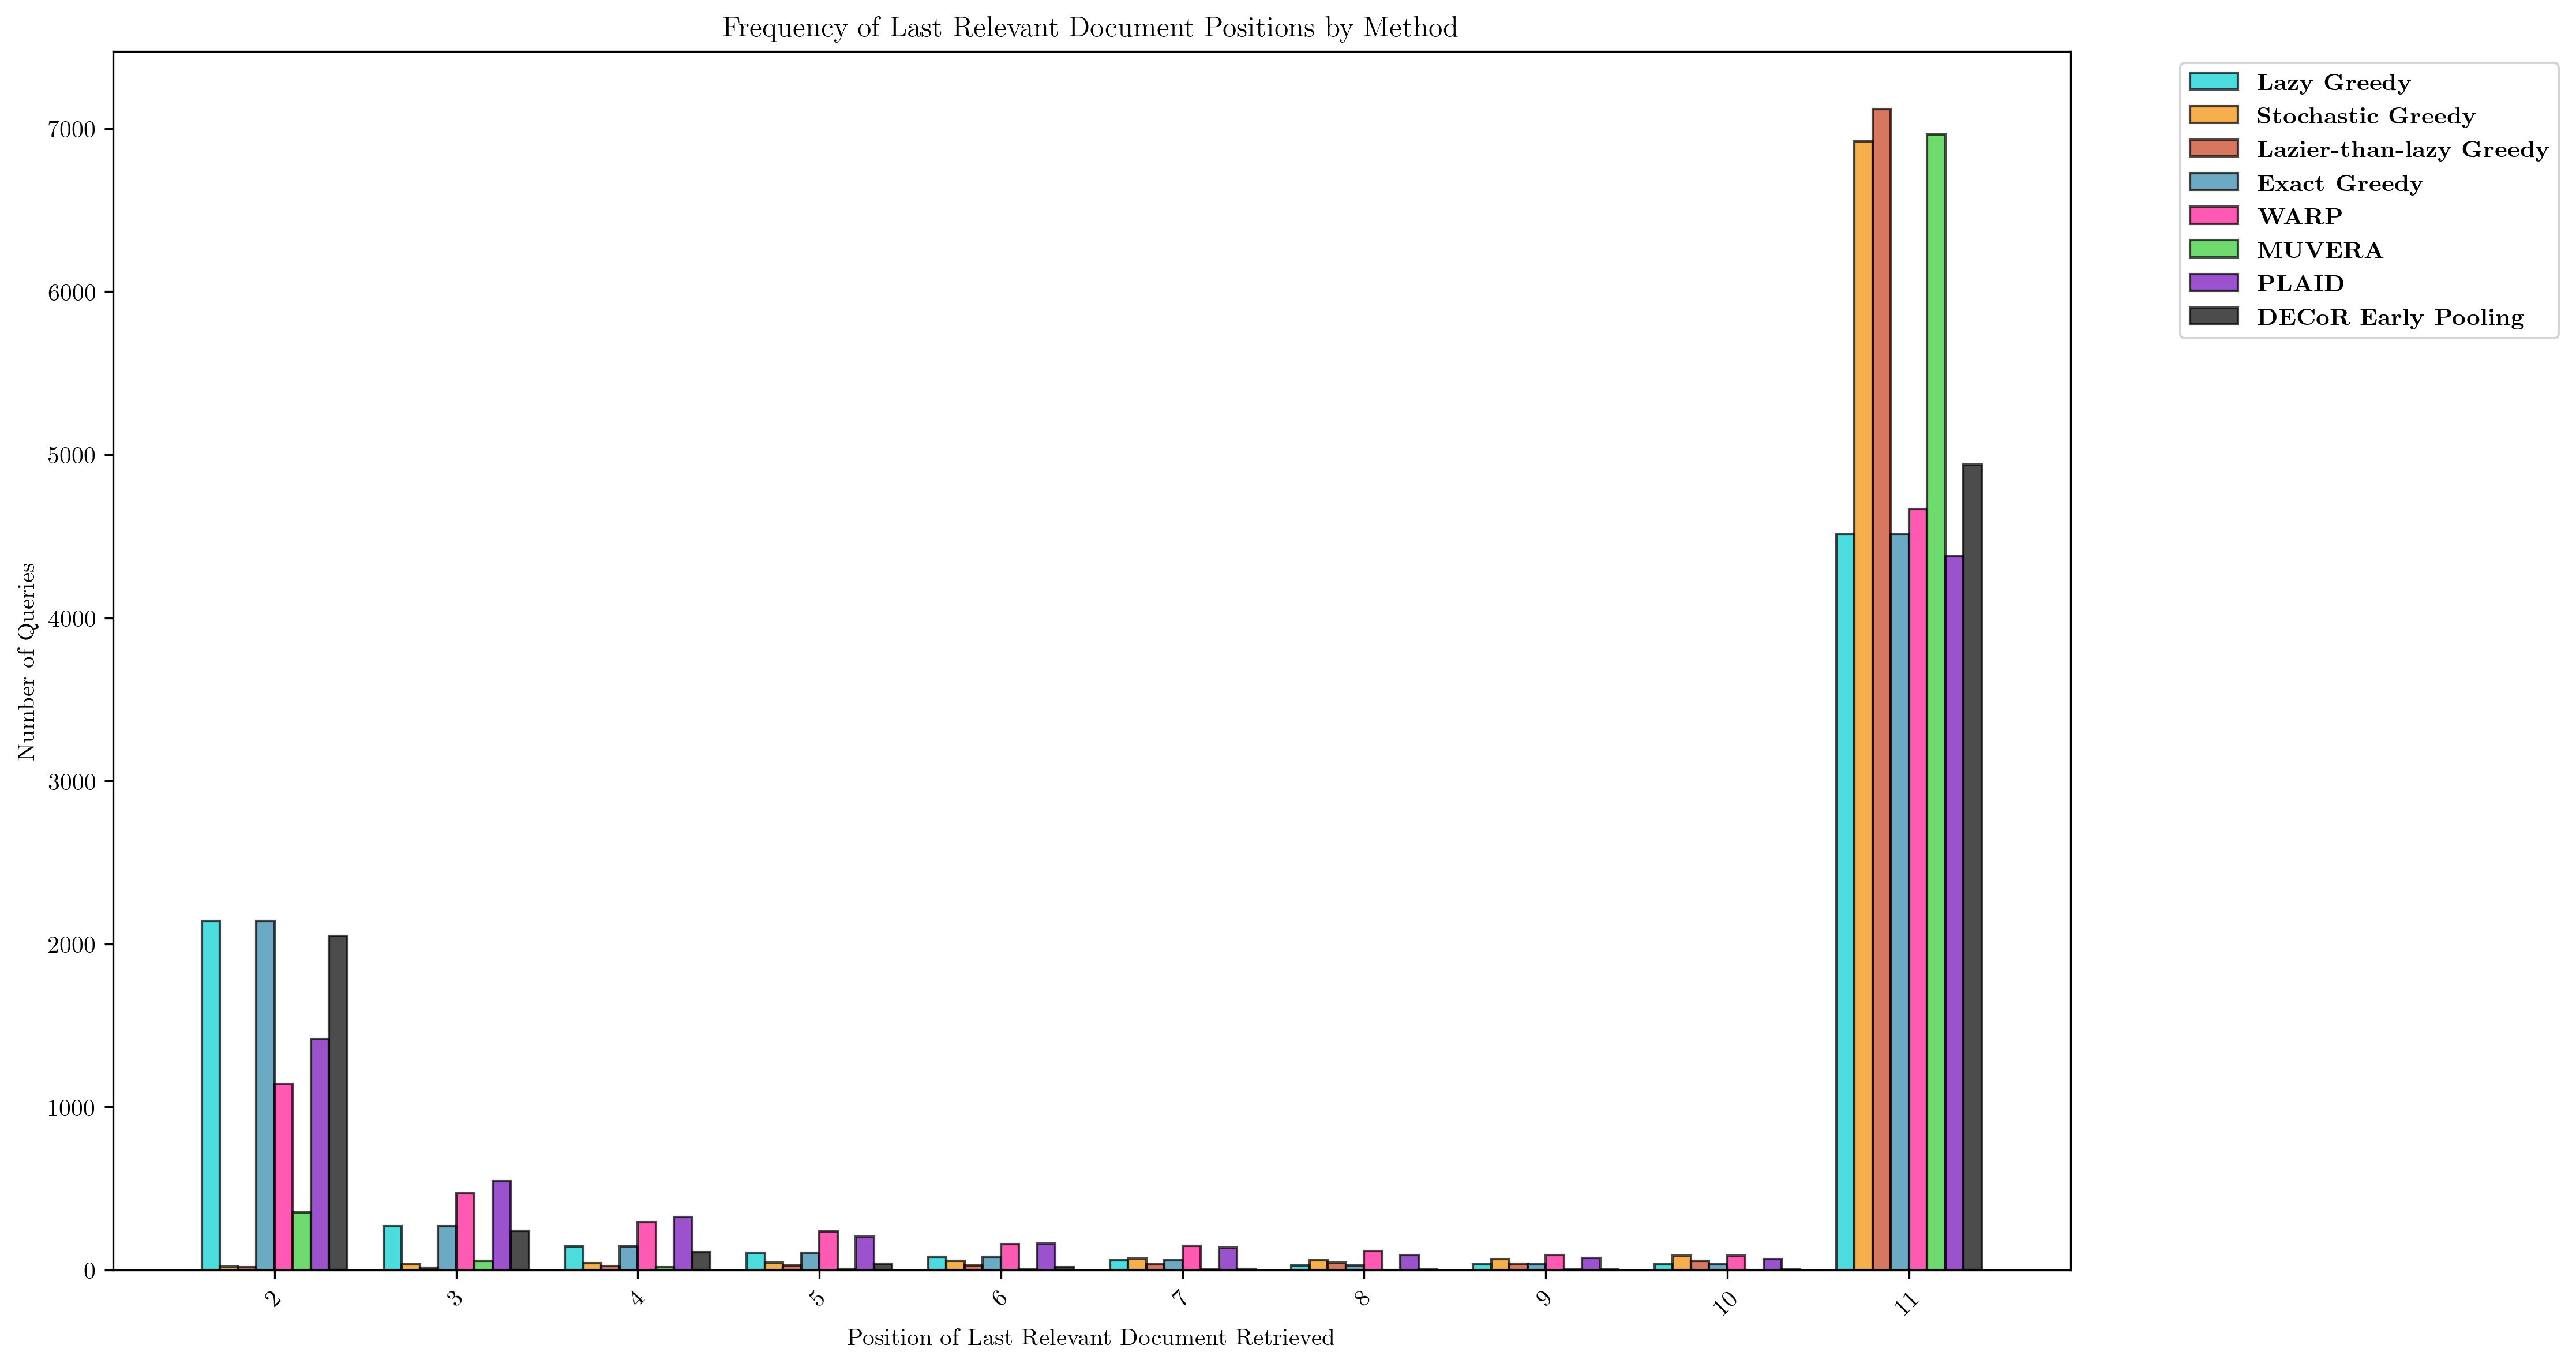

In [280]:
import pprint
# print("Scipy MAP")
# pprint.pprint(map_dict_1, indent=2)

# print("Other MAP")
# pprint.pprint(map_dict_2, indent=2)

# print("MRR")
# pprint.pprint(mrr_dict, indent=2)

# print("Mean Acc")
# pprint.pprint(acc_dict, indent=2)
methods_test = ['submodlib lazy', 'submodlib stochastic 0.5', 'submodlib ltl 0.5', 'exact greedy', 'WARP iid', 'MUVERA iid', 'ColBERT iid', 'ColBERT bypass - 1', 'gold']

import pandas as pd
from collections import Counter

print("Last rel Docs - Bar Plot")

# Get all unique positions across all methods
all_positions = set()
for method in methods_test:
    if method == 'gold':
        continue
    all_positions.update(last_rel_docs_dict[method])

all_positions = sorted(list(all_positions))

# Create data for grouped bar plot
data_for_plot = {}
for method in methods_test:
    if method == 'gold':
        continue
    
    # Count frequency of each position for this method
    position_counts = Counter(last_rel_docs_dict[method])
    method_counts = [position_counts.get(pos, 0) for pos in all_positions]
    data_for_plot[method] = method_counts

# Create DataFrame for easier plotting
df = pd.DataFrame(data_for_plot, index=all_positions)

# Create grouped bar plot
plt.figure(figsize=(15, 8))
width = 0.8 / len(df.columns)  # Width of each bar
x_positions = range(len(all_positions))

for i, method in enumerate(df.columns):
    if 'bypass' in method:
        color = 'black'
    elif 'ColBERT' in method and 'iid' in method:
        color = legend_color_map[method_label_map['ColBERT iid']]  # Use proper color mapping
    else:
        color = legend_color_map[method_label_map[method]]
    
    x_offset = [x + width * i for x in x_positions]
    plt.bar(x_offset, df[method], width, alpha=0.7, 
            label=method_label_map[method], color=color, edgecolor='black')

plt.xlabel('Position of Last Relevant Document Retrieved')
plt.ylabel('Number of Queries') 
plt.title('Frequency of Last Relevant Document Positions by Method')
plt.xticks([x + width * (len(df.columns) - 1) / 2 for x in x_positions], 
           all_positions, rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# print("Last rel Docs")
# for method in methods_test:
#     if method == 'gold':
#         continue
#     if 'bypass' in method:
#         color = 'black'
#     elif 'ColBERT' in method and 'iid' in method:
#         color = 'white'
#     else:
#         color = legend_color_map[method_label_map[method]]

#     # Bar plot of frequency of last relevant document positions
    
#     plt.bar()
#     plt.hist(last_rel_docs_dict[method], bins=10, alpha=0.6, label=method, color=color,
#              histtype='stepfilled', edgecolor='black')
# plt.xlabel('Position of Last Relevant Document Retrieved')
# plt.ylabel('Number of Queries')
# plt.title('Histogram of Last Relevant Document Positions by Method')
# plt.legend()
# plt.show()

In [ ]:
import pandas as pd
from collections import Counter

def histogram_processing(methods, last_rel_docs_dict):
    # Get all unique positions across all methods
    all_positions = set()
    for method in methods_test:
        if method == 'gold':
            continue
        all_positions.update(last_rel_docs_dict[method])

    all_positions = sorted(list(all_positions))

    # Create data for grouped bar plot
    data_for_plot = {}
    for method in methods_test:
        if method == 'gold':
            continue

        # Count frequency of each position for this method
        position_counts = Counter(last_rel_docs_dict[method])
        method_counts = [position_counts.get(pos, 0) for pos in all_positions]
        data_for_plot[method] = method_counts

    # Create DataFrame for easier plotting
    df = pd.DataFrame(data_for_plot, index=all_positions)

    # keep only positions <= 5
    positions_to_show = [p for p in all_positions if p <= 5]

    # slice the DataFrame
    df_small = df.loc[positions_to_show]

    return df_small, positions_to_show

In [416]:
import pandas as pd
from collections import Counter


def plot_histogram(last_rel_docs_dict):
    methods_test = ['submodlib lazy', 'submodlib stochastic 0.5', 'submodlib ltl 0.5', 'exact greedy', 'WARP iid', 'MUVERA iid', 'ColBERT iid', 'ColBERT bypass - 1', 'gold']

    print("Last rel Docs - Bar Plot")

    plt.rcParams.update({
        'text.usetex': True,
        'text.latex.preamble': r'\usepackage{amsmath}',
        'font.family': 'serif',
        'figure.dpi': 300,
        # 'lines.markersize': 12
    })

    df_small, positions_to_show = histogram_processing(methods_test, last_rel_docs_dict)
    fig, ax = plt.subplots(figsize=(15, 8))
    # plt.figure(figsize=(15, 8))
    width = 0.8 / len(df_small.columns)
    x_positions = range(len(positions_to_show))

    for i, method in enumerate(df_small.columns):
        if 'bypass' in method:
            color = 'black'
        elif 'ColBERT' in method and 'iid' in method:
            color = plot_utils.legend_color_map[method_label_map['ColBERT iid']]  # Use proper color mapping
        else:
            color = plot_utils.legend_color_map[method_label_map[method]]
        x_offset = [x + width * i for x in x_positions]
        plt.bar(x_offset, df_small[method], width, alpha=0.7,
                label=plot_utils.method_label_map[method], color=color, edgecolor='black',
                align='center')

    ax.set_xlabel(r'\textbf{Rank of Last Relevant Item Retrieved}', fontsize=48)
    ax.set_ylabel(r'\textbf{Number of Queries}', fontsize=48)
    # plt.title('Frequency of Last Relevant Document Positions by Method')
    plt.xticks([x + width * (len(df_small.columns) - 1) / 2 for x in x_positions],
            positions_to_show) #, rotation=45)
    # plt.xticks([2, 3, 4, 5])

    # Explicitly set tick label sizes
    ax.tick_params(axis='x', labelsize=60)  # Smaller X-axis tick labels
    ax.tick_params(axis='y', labelsize=60)  # Smaller Y-axis tick labels

    # Get current x-tick values and format them with LaTeX bold
    xticks = ax.get_xticks()
    # xticklabels = [fr'$\mathbf{{{int(v)}}}$' for v in xticks]
    # xticklabels = [r'$\mathbf{0}$', r'$\mathbf{2}$', r'$\mathbf{3}$', r'$\mathbf{4}$', r'$\mathbf{5}$']
    # ax.set_xticklabels(xticklabels)

    # Get current y-tick values and format them with LaTeX bold
    yticks = ax.get_yticks()
    yticklabels = [fr'$\mathbf{{{int(v)}}}$' for v in yticks]
    ax.set_yticklabels(yticklabels)

    # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f'./notebooks/plots/{dataset_name}_plot3_5_histogram.pdf', bbox_inches='tight', dpi=300)
    plt.show()


Last rel Docs - Bar Plot


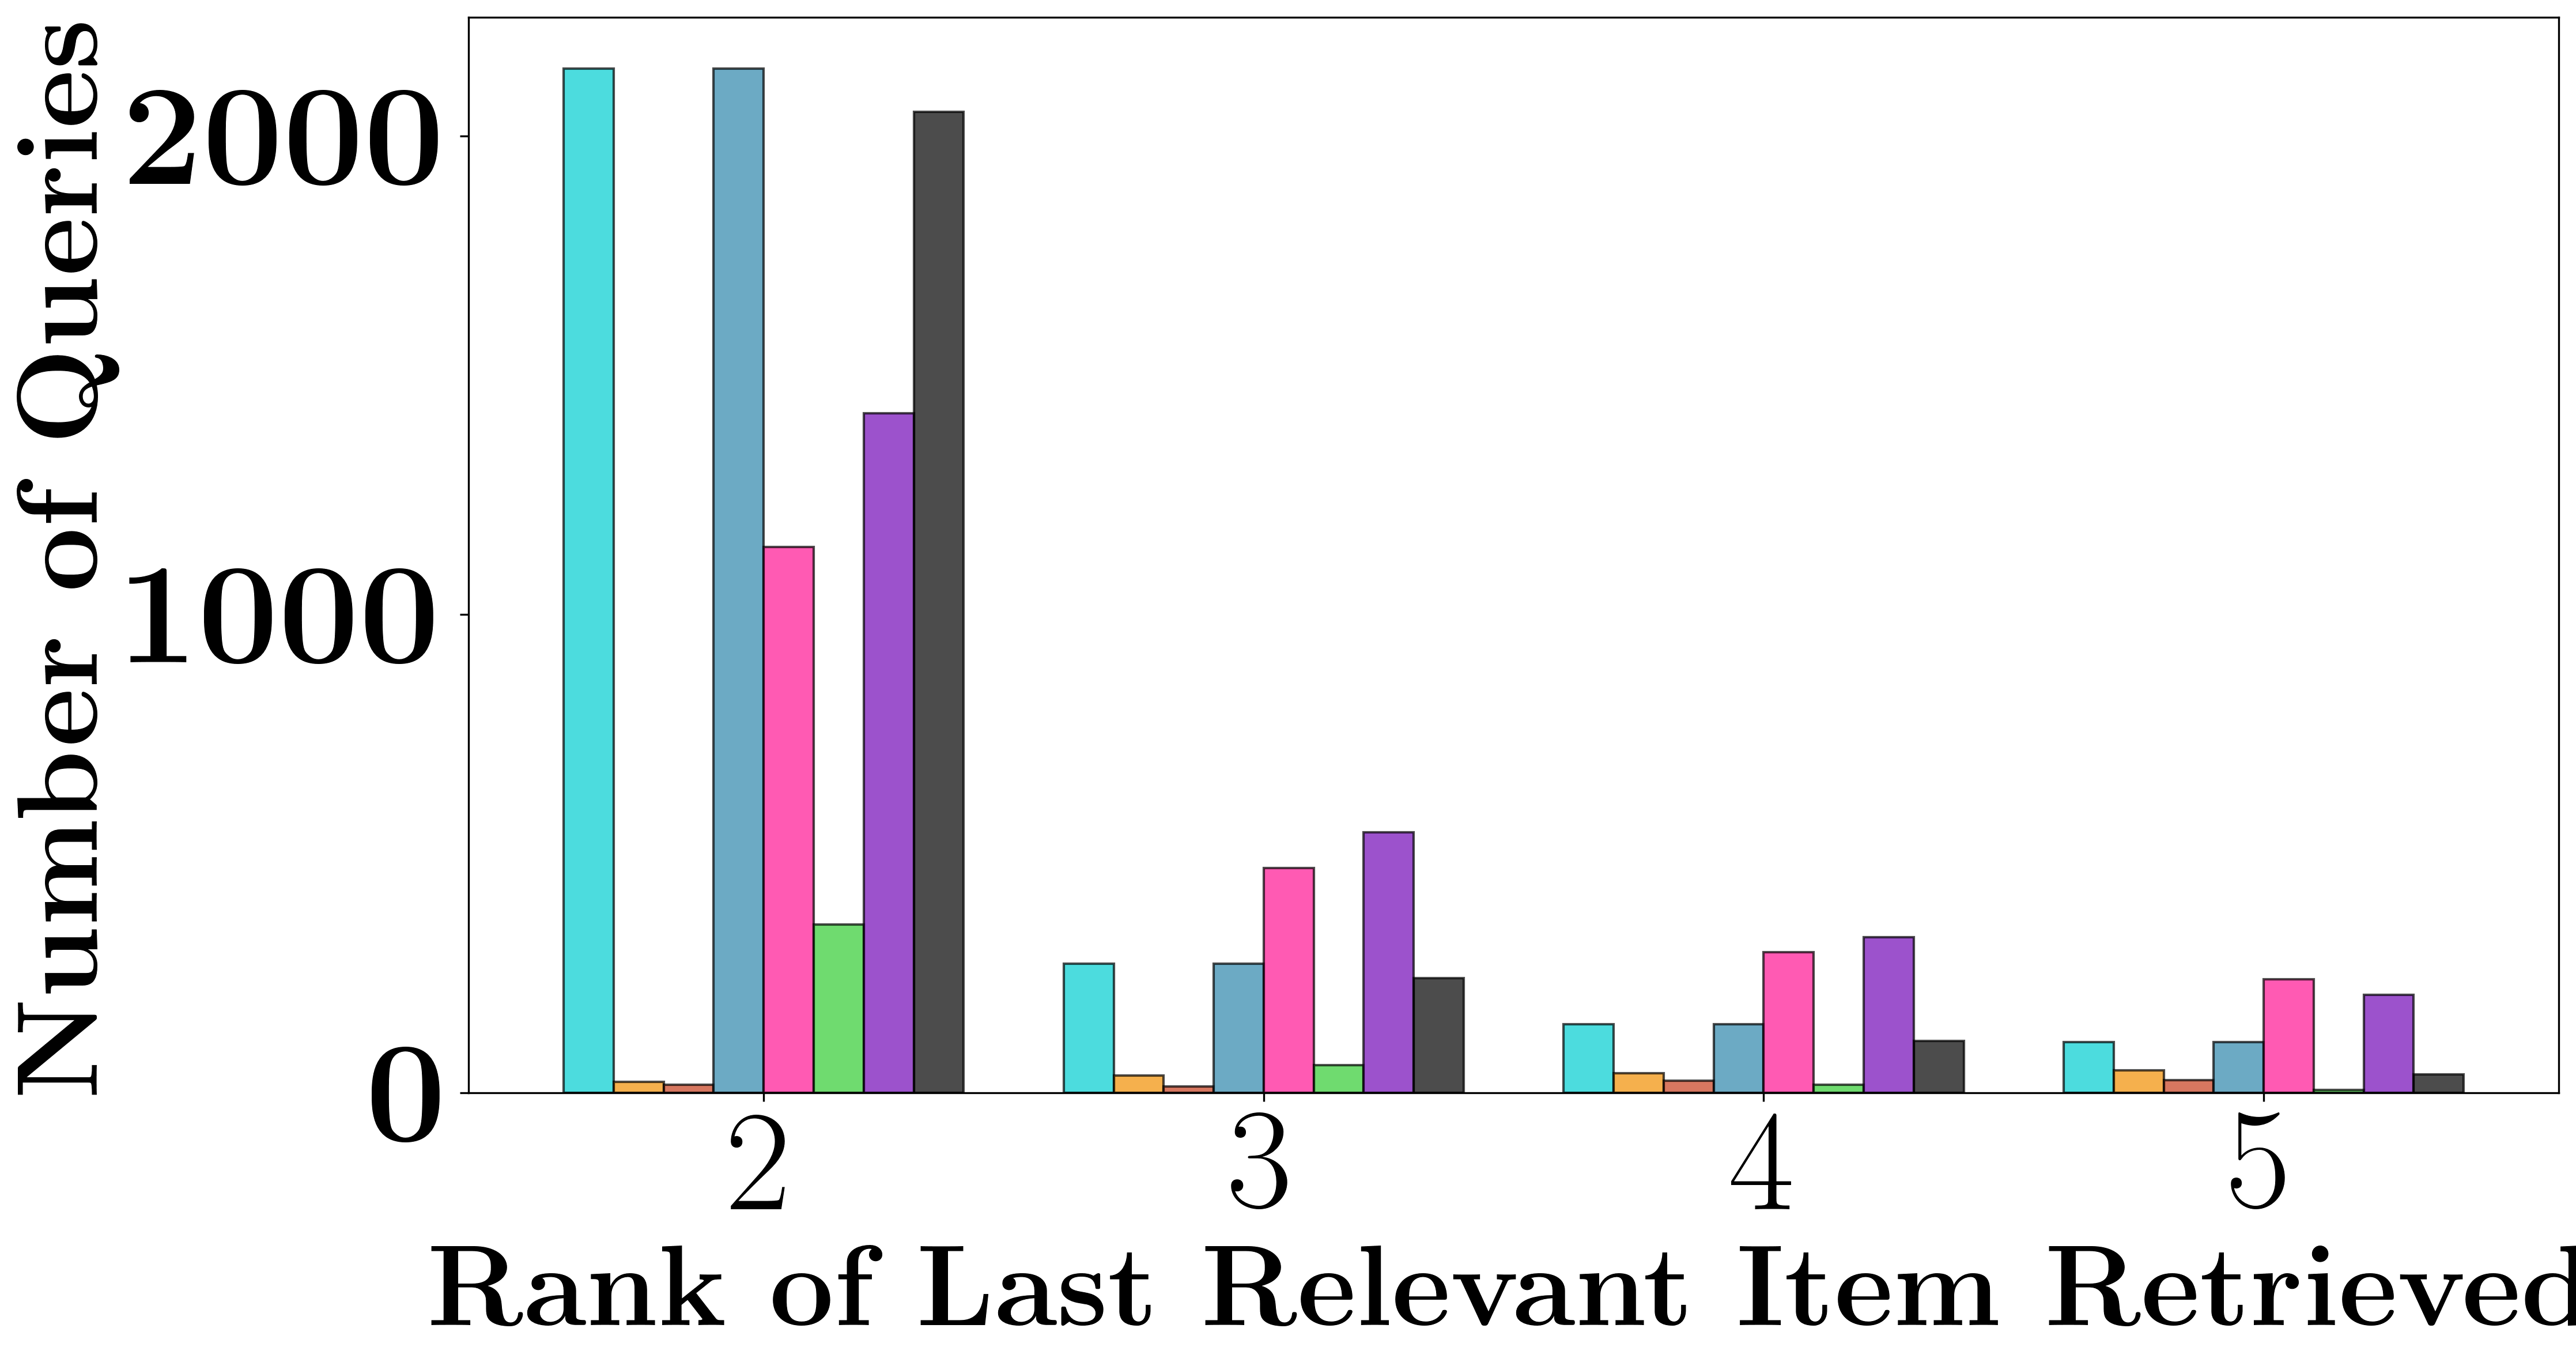

In [418]:
dataset_name = 'hotpotqa'
plot_histogram(last_rel_docs_dict)

In [329]:
import pandas as pd
from collections import Counter


def plot_histogram_legend(last_rel_docs_dict, filename, ncol=3, auto_crop=True):
    methods_test = ['ColBERT bypass - 1', 'submodlib ltl 0.5', 'exact greedy', 'MUVERA iid', 'submodlib lazy', 'WARP iid', 'submodlib stochastic 0.5', 'ColBERT iid']
    print("Last rel Docs - Bar Plot")

    plt.rcParams.update({
        'text.usetex': True,
        'text.latex.preamble': r'\usepackage{amsmath}',
        'font.family': 'serif',
        'figure.dpi': 300,
        'lines.markersize': 12
    })

    df_small, positions_to_show = histogram_processing(methods_test, last_rel_docs_dict)
    fig, ax = plt.subplots(figsize=(15, 8))
    # plt.figure(figsize=(15, 8))
    width = 0.8 / len(df_small.columns)
    x_positions = range(len(positions_to_show))

    for i, method in enumerate(df_small.columns):
        if 'bypass' in method:
            color = 'black'
        elif 'ColBERT' in method and 'iid' in method:
            color = plot_utils.legend_color_map[method_label_map['ColBERT iid']]  # Use proper color mapping
        else:
            color = plot_utils.legend_color_map[method_label_map[method]]
        x_offset = [x + width * i for x in x_positions]
        plt.bar([], [], width, alpha=0.7,
                label=plot_utils.method_label_map[method], color=color, edgecolor='black')

    # Create legend
    legend = ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.1),
        ncol=ncol,
        fontsize=25,
        frameon=False
    )

    # Save the figure
    output_path = f'./notebooks/plots/{filename}.pdf'
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0.1, dpi=300)
    plt.show()
    
    # Auto-crop the PDF if requested
    if auto_crop:
        # Try methods in order of preference
        cropped_path = crop_pdf_with_pdfcrop(output_path)
        if cropped_path is None:
            cropped_path = crop_pdf_with_fitz(output_path)
        if cropped_path is None:
            cropped_path = crop_pdf_with_pypdf(output_path)
        
        if cropped_path:
            # Replace original with cropped version
            os.rename(cropped_path, output_path)
            print(f"PDF automatically cropped: {output_path}")
        else:
            print("Auto-cropping failed, using matplotlib's bbox_inches='tight' only")


In [334]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def legend_only(methods_order, legend_color_map, method_label_map, filename, ncol=3):
    # Build labels & colors
    labels = [method_label_map[m] for m in methods_order]
    def color_for(m):
        if 'bypass' in m:
            return 'black'
        if 'ColBERT' in m and 'iid' in m:
            return plot_utils.legend_color_map[method_label_map['ColBERT iid']]
        return plot_utils.legend_color_map[method_label_map[m]]

    colors = [color_for(m) for m in methods_order]

    # Proxy handles for legend
    handles = [Patch(facecolor=c, edgecolor='black', label=lbl)
               for c, lbl in zip(colors, labels)]

    fig = plt.figure(figsize=(8, 2.2), dpi=300)
    # no axes at all
    leg = fig.legend(handles=handles,
                     loc="center", ncol=ncol, frameon=False, fontsize=30)
    fig.savefig(f'./notebooks/plots/{filename}.pdf',
                bbox_inches='tight', pad_inches=0.1)
    plt.show(fig)
    # plt.close(fig)


In [ ]:
dms = ['ColBERT bypass - 1', 'submodlib ltl 0.5', 'exact greedy', 'MUVERA iid', 'submodlib lazy', 'WARP iid', 'submodlib stochastic 0.5', 'ColBERT iid']

legend_only(dms, legend_color_map=plot_utils.legend_color_map,
            method_label_map=plot_utils.method_label_map, filename='plot_3_5_legend', ncol=4)


<Figure size 2400x660 with 0 Axes>

In [173]:
for dataset in datasets:
    for method in methods:
        if method == "gold":
            scores = gc_mean
        else:
            scores = score_map[dataset][method].tolist()[:2]

        print(f"Method: {method}, dataset: {dataset}, scores: {scores}")

Method: submodlib lazy, dataset: hotpotqa, scores: [20.77775001525879, 24.150075912475586]
Method: submodlib stochastic 0.5, dataset: hotpotqa, scores: [17.124168395996094, 21.010772705078125]
Method: submodlib ltl 0.1, dataset: hotpotqa, scores: [17.91053009033203, 21.84095001220703]
Method: submodlib ltl 0.5, dataset: hotpotqa, scores: [16.761524200439453, 20.62693977355957]
Method: submodlib ltl 0.9, dataset: hotpotqa, scores: [15.248700141906738, 18.867860794067383]
Method: exact greedy, dataset: hotpotqa, scores: [20.77775001525879, 24.150075912475586]
Method: WARP iid, dataset: hotpotqa, scores: [20.61368751525879, 22.261213302612305]
Method: MUVERA iid, dataset: hotpotqa, scores: [18.806304931640625, 20.090028762817383]
Method: ColBERT iid, dataset: hotpotqa, scores: [20.762149810791016, 22.529996871948242]
Method: ColBERT bypass - 1, dataset: hotpotqa, scores: [20.763174057006836, 24.108600616455078]
Method: ColBERT angiogram - 1, dataset: hotpotqa, scores: [20.756580352783203,

### QRels avg and max set size

In [222]:
# Check msmarco specifically
class DummyConfig:
    loader_type = 'beir'
    dataset_name = 'msmarco'

dloader = get_dataloader(DummyConfig())
qrels_msmarco = dloader.get_qrels()
qrels_msmarco[0]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8841823/8841823 [00:36<00:00, 245223.17it/s]



KeyError: 0

In [224]:
qrels_msmarco['19335']

{'1017759': 0,
 '1082489': 0,
 '109063': 0,
 '1160863': 0,
 '1160871': 0,
 '1189088': 0,
 '1203500': 0,
 '1231806': 0,
 '1231807': 0,
 '1274615': 0,
 '1274620': 0,
 '1324075': 0,
 '1509459': 0,
 '1555317': 0,
 '1568085': 0,
 '161603': 0,
 '1705525': 0,
 '1720387': 0,
 '1720388': 0,
 '1720389': 1,
 '1720393': 0,
 '1720395': 1,
 '1722': 0,
 '1725697': 0,
 '1726': 0,
 '1729': 2,
 '1730': 0,
 '1796642': 0,
 '1796647': 0,
 '1825416': 0,
 '1825418': 0,
 '1837110': 0,
 '1871222': 0,
 '1908804': 0,
 '1956669': 0,
 '1958100': 0,
 '1958102': 0,
 '1958103': 0,
 '1959553': 0,
 '2004186': 0,
 '2046505': 1,
 '2071723': 0,
 '2130187': 0,
 '2186129': 0,
 '2304004': 0,
 '2304005': 0,
 '2324839': 0,
 '2325143': 0,
 '2382766': 0,
 '2394677': 0,
 '256744': 0,
 '256746': 0,
 '256750': 0,
 '2594897': 0,
 '2604487': 0,
 '2725017': 0,
 '2874503': 0,
 '2943092': 0,
 '2978577': 0,
 '3045565': 1,
 '3045567': 1,
 '3137952': 0,
 '3175481': 3,
 '3175483': 0,
 '3175484': 3,
 '3175485': 0,
 '3212083': 0,
 '3260688': 

In [231]:
# Check pooled specifically
class DummyConfig:
    loader_type = 'lotte'
    query_type = 'forum'
    dataset_name = 'pooled'

dloader = get_dataloader(DummyConfig())
qrels_pooled = dloader.get_qrels()

In [233]:
qrels_pooled['0']

['14298',
 '14300',
 '14311',
 '14314',
 '14333',
 '14341',
 '14346',
 '14349',
 '14350',
 '14356',
 '14360',
 '14367',
 '14383',
 '14400',
 '14505',
 '14534',
 '14549',
 '41500',
 '161058',
 '163178']

In [248]:
# Check msmarco specifically
class DummyConfig:
    loader_type = 'beir'
    dataset_name = 'fever'

dloader = get_dataloader(DummyConfig())
qrels_fever = dloader.get_qrels()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5416568/5416568 [00:27<00:00, 198021.60it/s]


In [250]:
qrels_fever['163803']

{'Ukrainian_Soviet_Socialist_Republic': 1, 'United_Nations': 1}

In [406]:
class DummyConfig:
    loader_type = 'lotte'
    query_type = 'forum'
    dataset_name = 'pooled'

dloader = get_dataloader(DummyConfig())
qrels = dloader.get_qrels()

list(qrels.values())[0]

['14298',
 '14300',
 '14311',
 '14314',
 '14333',
 '14341',
 '14346',
 '14349',
 '14350',
 '14356',
 '14360',
 '14367',
 '14383',
 '14400',
 '14505',
 '14534',
 '14549',
 '41500',
 '161058',
 '163178']

In [442]:
for dataset in ['lifestyle', 'recreation', 'pooled', 'science', 'technology', 'writing']:
    class DummyConfig:
        loader_type = 'lotte'
        query_type = 'forum'
        dataset_name = dataset

    dloader = get_dataloader(DummyConfig())
    qrels = dloader.get_qrels()
    _, queries = dloader.get_data()
    print(f"Dataset: {dataset}, Number of queries with at least one relevant doc: {len(qrels)}")
    # print(f"Avg relevant docs per query: {np.mean([len(v) for v in qrels.values()])}")
    # print(f"Maximum relevant docs for a single query: {max(len(v) for v in qrels.values())}")
    # print(f"# of queries with atleast one relevant doc: {sum(1 for v in qrels.values() if len(v) > 0)}")
    # print(f"# of queries with atleast two relevant docs: {sum(1 for v in qrels.values() if len(v) > 1)}")
    print(f"Fraction of queries with atleast two relevant docs: {sum(1 for v in qrels.values() if len(v) > 1) / len(queries)}")

Dataset: lifestyle, Number of queries with at least one relevant doc: 2002
Fraction of queries with atleast two relevant docs: 0.9015984015984015
Dataset: recreation, Number of queries with at least one relevant doc: 2002
Fraction of queries with atleast two relevant docs: 0.7887112887112887
Dataset: pooled, Number of queries with at least one relevant doc: 10025
Fraction of queries with atleast two relevant docs: 0.9049376558603491
Dataset: science, Number of queries with at least one relevant doc: 2017
Fraction of queries with atleast two relevant docs: 0.9211700545364403
Dataset: technology, Number of queries with at least one relevant doc: 2004
Fraction of queries with atleast two relevant docs: 0.9565868263473054
Dataset: writing, Number of queries with at least one relevant doc: 2000
Fraction of queries with atleast two relevant docs: 0.9565


In [431]:
for dataset in ['msmarco']:
    class DummyConfig:
        loader_type = 'beir'
        dataset_name = dataset

    dloader = get_dataloader(DummyConfig())
    qrels = dloader.get_qrels()
    print(list(qrels.values())[:10])
    _, queries = dloader.get_data()
    print(f"Dataset: {dataset}, Number of queries with at least one relevant doc: {len(qrels)}")
    # print(f"Avg relevant docs per query: {np.mean([len([val for val in v.values() if val >= 1]) for v in qrels.values()])}")
    print(f"Number of queries with atleast one relevant doc: {len([1 for v in qrels.values() if len([val for val in v.values() if val >= 1]) > 1])}")
    # print(f"Maximum value of relevance label: {max([max([int(val) for val in v.values()]) for v in qrels.values()])}")
    # print(f"Maximum relevant docs for a single query: {max(len([val for val in v.values() if val >= 1]) for v in qrels.values())}")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8841823/8841823 [01:11<00:00, 123319.74it/s]


[{'1017759': 0, '1082489': 0, '109063': 0, '1160863': 0, '1160871': 0, '1189088': 0, '1203500': 0, '1231806': 0, '1231807': 0, '1274615': 0, '1274620': 0, '1324075': 0, '1509459': 0, '1555317': 0, '1568085': 0, '161603': 0, '1705525': 0, '1720387': 0, '1720388': 0, '1720389': 1, '1720393': 0, '1720395': 1, '1722': 0, '1725697': 0, '1726': 0, '1729': 2, '1730': 0, '1796642': 0, '1796647': 0, '1825416': 0, '1825418': 0, '1837110': 0, '1871222': 0, '1908804': 0, '1956669': 0, '1958100': 0, '1958102': 0, '1958103': 0, '1959553': 0, '2004186': 0, '2046505': 1, '2071723': 0, '2130187': 0, '2186129': 0, '2304004': 0, '2304005': 0, '2324839': 0, '2325143': 0, '2382766': 0, '2394677': 0, '256744': 0, '256746': 0, '256750': 0, '2594897': 0, '2604487': 0, '2725017': 0, '2874503': 0, '2943092': 0, '2978577': 0, '3045565': 1, '3045567': 1, '3137952': 0, '3175481': 3, '3175483': 0, '3175484': 3, '3175485': 0, '3212083': 0, '3260688': 0, '3358752': 0, '342431': 0, '342432': 0, '3424644': 0, '3445057'

In [439]:
count = 0
for v in qrels.values():
    if len([val for val in v.values() if val > 1]) > 1:
        print([val for val in v.values() if val > 1])
        count += 1
count

[2, 3, 3, 2, 3, 2, 3]
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 3, 2, 2, 2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2]
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
[2, 3, 3, 2, 2, 2, 2, 2, 2, 3, 2, 2, 3, 2, 3, 2, 2, 2, 2, 2, 3, 3, 3, 3, 2, 3, 2, 2, 3, 2, 2]
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
[2, 2, 2, 2, 2, 2, 3, 2, 3, 3, 2, 3, 3, 3]
[3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3]
[2, 2, 2, 2, 2, 3, 2, 2]
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2]
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 

43

In [424]:
dataset = 'fever'
class DummyConfig:
    loader_type = 'beir'
    dataset_name = dataset

dloader = get_dataloader(DummyConfig())
corpus, queries = dloader.get_data()
qrels = dloader.get_qrels()

print(f"Dataset: {dataset}, Number of queries with at least one relevant doc: {len(qrels)}")
# print(f"Avg relevant docs per query: {np.mean([len([val for val in v.values() if val >= 1]) for v in qrels.values()])}")
# print(f"Number of queries with atleast one relevant doc: {len([1 for v in qrels.values() if len([val for val in v.values() if val >= 1]) >= 1])}")
print(f"Fraction of queries with more than one relevant doc: {[val for val in qrels.values() if len(val) > 1]}")
# print(f"Maximum value of relevance label: {max([max([int(val) for val in v.values()]) for v in qrels.values()])}")
# print(f"Maximum relevant docs for a single query: {max(len([val for val in v.values() if val >= 1]) for v in qrels.values())}")


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5416568/5416568 [00:50<00:00, 106299.43it/s]


Dataset: fever, Number of queries with at least one relevant doc: 6666
Fraction of queries with more than one relevant doc: [{'Ukrainian_Soviet_Socialist_Republic': 1, 'United_Nations': 1}, {'Commodore_(rank)': 1, 'Rear_admiral': 1}, {'Electric_chair': 1, 'Capital_punishment': 1}, {'Zoe_Saldana': 1, 'Leo_(astrology)': 1}, {'Chesley_Sullenberger': 1, 'US_Airways_Flight_1549': 1}, {'Kevin_Bacon': 1, 'Sleepers': 1}, {'Indiana_Pacers': 1, 'Chris_Mullin_(basketball)': 1}, {'Far_from_the_Madding_Crowd_(1967_film)': 1, 'Nicolas_Roeg': 1}, {'Benzodiazepine': 1, 'Premedication': 1}, {'Anne_Boleyn': 1, 'Claude_of_France': 1}, {'66th_Primetime_Emmy_Awards': 1, '66th_Primetime_Creative_Arts_Emmy_Awards': 1}, {'Deepika_Padukone': 1, 'Yeh_Jawaani_Hai_Deewani': 1}, {'Baja_1000': 1, 'Vince_Vaughn': 1}, {'Bob_Ross': 1, 'The_Joy_of_Painting': 1}, {'Phoenix,_Arizona': 1, 'Arizona': 1}, {'Phoenix,_Arizona': 1, 'Phoenix_metropolitan_area': 1}, {'Nick_Nolte': 1, 'Ben_Chaplin': 1, 'The_Thin_Red_Line_(1998_fi

In [427]:
print(f"Fraction of queries with more than one relevant doc: {len([val for val in qrels.values() if len(val) > 1]) / len(queries)}")

Fraction of queries with more than one relevant doc: 0.12706270627062707


In [399]:
print(f"Number of queries with exactly one relevant doc: {len([1 for v in qrels.values() if len([val for val in v.values() if val >= 1]) == 1])}")

Number of queries with exactly one relevant doc: 5819


In [400]:
print(f"Number of queries with two relevant doc: {len([1 for v in qrels.values() if len([val for val in v.values() if val >= 1]) == 2])}")

Number of queries with two relevant doc: 654


In [401]:
print(f"Number of queries with atleast two relevant doc: {len([1 for v in qrels.values() if len([val for val in v.values() if val >= 1]) >= 2])}")

Number of queries with atleast two relevant doc: 847


In [396]:
print(f"Number of queries with three relevant doc: {len([1 for v in qrels.values() if len([val for val in v.values() if val >= 1]) == 3])}")

Number of queries with three relevant doc: 110


In [402]:
dataset = 'hotpotqa'
class DummyConfig:
    loader_type = 'beir'
    dataset_name = dataset

dloader = get_dataloader(DummyConfig())
qrels = dloader.get_qrels()
print(f"Dataset: {dataset}, Number of queries with at least one relevant doc: {len(qrels)}")
print(f"Avg relevant docs per query: {np.mean([len([val for val in v.values() if val >= 1]) for v in qrels.values()])}")
print(f"Maximum value of relevance label: {max([max([int(val) for val in v.values()]) for v in qrels.values()])}")
print(f"Maximum relevant docs for a single query: {max(len([val for val in v.values() if val >= 1]) for v in qrels.values())}")


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5233329/5233329 [00:43<00:00, 120147.98it/s]


Dataset: hotpotqa, Number of queries with at least one relevant doc: 7405
Avg relevant docs per query: 2.0
Maximum value of relevance label: 1
Maximum relevant docs for a single query: 2


In [410]:
gc_mean

array([20.54772 , 23.517984], dtype=float32)